# Student Dropout Risk Predictor for Secondary Schools

**3MTT Capstone Project | Nigeria**

A binary classifier that flags secondary-school students at risk of dropping out, using
attendance, early-term grades, and household background, so that a school can intervene
while there is still time in the academic year.

**What this notebook produces**
1. A documented, non-leaky proxy target for "at risk"
2. Four trained models with cross-validated comparison
3. A full evaluation suite tuned for **recall on the at-risk class**
4. Global and per-student explanations (permutation importance and SHAP)
5. A saved model plus preprocessing pipeline for the Streamlit app

**Important honesty note.** The dataset has no ground-truth dropout column. We construct a
transparent proxy target and label it as such throughout. Section 3 documents the rule, and
the README repeats the caveat. Nothing in this notebook should be read as a validated
prediction of actual dropout.

## 1. Setup

In [1]:
# Colab bootstrap. Safe to re-run locally: only installs what is missing.
import importlib, subprocess, sys

REQUIRED = {"pandas": "pandas", "numpy": "numpy", "sklearn": "scikit-learn",
            "matplotlib": "matplotlib", "seaborn": "seaborn", "shap": "shap",
            "imblearn": "imbalanced-learn", "joblib": "joblib"}
missing = [pkg for mod, pkg in REQUIRED.items() if not importlib.util.find_spec(mod)]
if missing:
    print("Installing:", ", ".join(missing))
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=True)
else:
    print("All required packages already present.")

All required packages already present.


In [2]:
import warnings, json, io, zipfile, urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import (train_test_split, StratifiedKFold, cross_validate)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, average_precision_score, confusion_matrix,
                             roc_curve, precision_recall_curve, ConfusionMatrixDisplay)
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 150, "savefig.bbox": "tight",
                     "font.size": 10, "axes.titleweight": "bold"})

ROOT = Path.cwd()
DATA_DIR, EVAL_DIR = ROOT / "data", ROOT / "evaluation"
PLOT_DIR, MODEL_DIR = EVAL_DIR / "plots", ROOT / "models"
for d in (DATA_DIR, EVAL_DIR, PLOT_DIR, MODEL_DIR):
    d.mkdir(parents=True, exist_ok=True)

print(f"pandas {pd.__version__} | numpy {np.__version__} | shap {shap.__version__}")
print(f"Working directory: {ROOT}")

pandas 3.0.3 | numpy 2.4.6 | shap 0.52.0
Working directory: C:\Users\USER\OneDrive\Desktop\capstone project


### Configuration

Every tunable lives here so the notebook can be re-run under different policy choices.
The **risk band thresholds are configurable** as required.

In [3]:
CONFIG = {
    # Risk band cutoffs applied to the predicted probability of being at risk.
    "risk_bands": {"low_max": 0.33, "medium_max": 0.66},

    # Proxy target: a student is "at risk" if the final grade falls below the pass mark.
    "pass_mark": 10,          # on the dataset's 0-20 scale
    "grade_scale_max": 20,

    # Features dropped to prevent target leakage. Justified in section 3.
    "leaky_features": ["G3", "G2"],

    "test_size": 0.20,
    "cv_folds": 5,
    "random_state": RANDOM_STATE,

    # The at-risk class is the positive class. Recall on it is the headline metric.
    "primary_metric": "recall",
}

def to_band(p, bands=None):
    '''Map a probability to a risk band. Vectorised over arrays or scalars.'''
    b = bands or CONFIG["risk_bands"]
    edges = [b["low_max"], b["medium_max"]]
    return np.select([np.asarray(p) < edges[0], np.asarray(p) <= edges[1]],
                     ["Low", "Medium"], default="High")

assert CONFIG["risk_bands"]["low_max"] < CONFIG["risk_bands"]["medium_max"], \
    "FAIL: risk band edges out of order"
print("Risk bands: Low < {low_max} | Medium <= {medium_max} | High above".format(**CONFIG["risk_bands"]))
print("Spot check:", dict(zip([0.1, 0.5, 0.9], to_band([0.1, 0.5, 0.9]))))

Risk bands: Low < 0.33 | Medium <= 0.66 | High above
Spot check: {0.1: np.str_('Low'), 0.5: np.str_('Medium'), 0.9: np.str_('High')}


In [4]:
def check(label, condition, detail=""):
    '''Assertion that names its own failure cause, per the project validation policy.'''
    status = "PASS" if condition else "FAIL"
    line = f"  [{status}] {label}" + (f" -> {detail}" if detail else "")
    print(line)
    if not condition:
        raise AssertionError(f"{label}. {detail}")

def section(title):
    print("\n" + "=" * 74 + f"\n{title}\n" + "=" * 74)

print("Validation helpers ready.")

Validation helpers ready.


## 2. Load the data

**Source.** UCI Machine Learning Repository, *Student Performance* (Cortez and Silva, 2008).
<https://archive.ics.uci.edu/dataset/320/student+performance>

Two secondary-school cohorts from Portugal, collected via school reports and questionnaires:
`student-por.csv` (Portuguese language, 649 students) and `student-mat.csv` (Mathematics,
395 students). Both carry `absences` (attendance) and `G1`, `G2`, `G3` (period grades),
which is what this project needs.

**Why not a Nigerian dataset?** We searched for a public, student-level Nigerian or African
secondary-school dataset carrying an actual dropout or enrolment outcome and did not find
one. The nearest public options are Portuguese *higher-education* records and a Nigerian
*tertiary* GPA dataset, neither of which is secondary-school attendance data. This is a real
limitation, recorded in the README: the model is trained on Portuguese secondary schools and
the socioeconomic structure of dropout in Nigeria differs. The pipeline is built so that a
Nigerian dataset with the same columns can be dropped in directly.

In [5]:
section("STAGE 1: LOAD")

UCI_ZIP = "https://archive.ics.uci.edu/static/public/320/student+performance.zip"

def ensure_data():
    '''Download and extract the UCI archive if the CSVs are not already on disk.'''
    wanted = ["student-por.csv", "student-mat.csv"]
    if all((DATA_DIR / f).exists() for f in wanted):
        print("Local CSVs found, skipping download.")
        return
    print(f"Downloading {UCI_ZIP}")
    raw = urllib.request.urlopen(UCI_ZIP, timeout=60).read()
    outer = zipfile.ZipFile(io.BytesIO(raw))
    # The UCI archive nests a second zip containing the CSVs.
    if "student.zip" in outer.namelist():
        inner = zipfile.ZipFile(io.BytesIO(outer.read("student.zip")))
        for f in wanted:
            (DATA_DIR / f).write_bytes(inner.read(f))
    else:
        for f in wanted:
            (DATA_DIR / f).write_bytes(outer.read(f))
    print("Extracted:", ", ".join(wanted))

ensure_data()

por = pd.read_csv(DATA_DIR / "student-por.csv", sep=";")
mat = pd.read_csv(DATA_DIR / "student-mat.csv", sep=";")

print(f"\nstudent-por.csv shape: {por.shape}")
print(f"student-mat.csv shape: {mat.shape}")
check("Portuguese cohort row count matches the UCI documentation", por.shape == (649, 33),
      f"got {por.shape}, expected (649, 33)")
check("Mathematics cohort row count matches the UCI documentation", mat.shape == (395, 33),
      f"got {mat.shape}, expected (395, 33)")


STAGE 1: LOAD
Local CSVs found, skipping download.

student-por.csv shape: (649, 33)
student-mat.csv shape: (395, 33)
  [PASS] Portuguese cohort row count matches the UCI documentation -> got (649, 33), expected (649, 33)
  [PASS] Mathematics cohort row count matches the UCI documentation -> got (395, 33), expected (395, 33)


### 2.1 Data-integrity check: the two files overlap

The UCI documentation notes that 382 students appear in **both** files. Naively concatenating
the two CSVs would place the same student in the training set and the test set, inflating every
score. We verify the overlap before deciding what to model on.

In [6]:
MERGE_KEYS = ["school", "sex", "age", "address", "famsize", "Pstatus", "Medu", "Fedu",
              "Mjob", "Fjob", "reason", "nursery", "internet"]

overlap = por.merge(mat, on=MERGE_KEYS, how="inner")
por_keys = set(map(tuple, por[MERGE_KEYS].astype(str).values))
mat_only_mask = np.array([tuple(r) not in por_keys for r in mat[MERGE_KEYS].astype(str).values])

print(f"Students matched across both files : {len(overlap)}  (UCI documents 382)")
print(f"Mathematics-only students          : {mat_only_mask.sum()}")
print(f"Naive concatenation would give     : {len(por) + len(mat)} rows "
      f"for {len(por) + mat_only_mask.sum()} distinct students")
check("Documented 382-student overlap reproduces", len(overlap) == 382, f"got {len(overlap)}")

Students matched across both files : 382  (UCI documents 382)
Mathematics-only students          : 25
Naive concatenation would give     : 1044 rows for 674 distinct students
  [PASS] Documented 382-student overlap reproduces -> got 382


**Decision: model on the Portuguese cohort alone (n = 649).**

- Concatenating both files duplicates 382 students across the train/test boundary. That is
  leakage, and it is the single easiest way to report a fake score.
- The 25 Mathematics-only students could be appended, but their target would mean
  "failed Mathematics" while the other 649 mean "failed Portuguese". Mixing two subject
  definitions into one label to gain 3.7% more rows is a bad trade for a target this
  sensitive.
- 649 is the larger single-subject cohort, so we keep the whole of it.

In [7]:
df = por.copy()
print(f"Modelling cohort shape: {df.shape}\n")

print("--- dtypes ---")
print(df.dtypes.value_counts().to_string())
print("\n--- null counts (all columns) ---")
nulls = df.isna().sum()
print(f"Total nulls across all {df.shape[1]} columns: {int(nulls.sum())}")
print("Columns with any null:", list(nulls[nulls > 0].index) or "none")

print("\n--- first 3 rows, selected columns ---")
print(df[["school", "sex", "age", "studytime", "failures", "absences", "G1", "G2", "G3"]].head(3).to_string())

print("\n--- numeric summary of the columns this project centres on ---")
print(df[["absences", "G1", "G2", "G3", "failures"]].describe().round(2).to_string())

check("No missing values anywhere in the cohort", int(nulls.sum()) == 0, f"{int(nulls.sum())} nulls found")
check("Grades sit on the documented 0-20 scale",
      all(df[g].between(0, CONFIG["grade_scale_max"]).all() for g in ["G1", "G2", "G3"]),
      "a grade fell outside 0-20")
check("Absences are non-negative", (df["absences"] >= 0).all())

Modelling cohort shape: (649, 33)

--- dtypes ---


str      17
int64    16

--- null counts (all columns) ---
Total nulls across all 33 columns: 0
Columns with any null: none

--- first 3 rows, selected columns ---
  school sex  age  studytime  failures  absences  G1  G2  G3
0     GP   F   18          2         0         4   0  11  11
1     GP   F   17          2         0         2   9  11  11
2     GP   F   15          2         0         6  12  13  12

--- numeric summary of the columns this project centres on ---


       absences      G1      G2      G3  failures
count    649.00  649.00  649.00  649.00    649.00
mean       3.66   11.40   11.57   11.91      0.22
std        4.64    2.75    2.91    3.23      0.59
min        0.00    0.00    0.00    0.00      0.00
25%        0.00   10.00   10.00   10.00      0.00
50%        2.00   11.00   11.00   12.00      0.00
75%        6.00   13.00   13.00   14.00      0.00
max       32.00   19.00   19.00   19.00      3.00
  [PASS] No missing values anywhere in the cohort -> 0 nulls found
  [PASS] Grades sit on the documented 0-20 scale -> a grade fell outside 0-20
  [PASS] Absences are non-negative


## 3. Constructing the proxy target

### 3.1 The rule

There is no dropout column in this data. We define a **proxy** label:

> **`at_risk = 1` if the student's final grade `G3` is below the pass mark of 10 out of 20,
> otherwise `0`.**

### 3.2 Why this rule, and what it does and does not mean

A student who finishes the year below the pass mark does not progress and must repeat.
**Grade repetition is one of the most consistently documented antecedents of dropout** in
secondary education, including in Nigerian and wider West African settings: repeating pushes
a student off the age-for-grade track, raises the direct and opportunity cost of staying, and
sharply raises the probability of leaving.

So this target identifies **the population a dropout-prevention programme would want to reach**,
which is the operational question a school actually faces. It is not a dropout observation.
Concretely:

- A student flagged here failed the year. Most such students do **not** drop out.
- A student who leaves school for reasons unrelated to grades, for example early marriage,
  a family income shock, or displacement, is **invisible** to this label.

The honest description is: *this model predicts end-of-year academic failure, which is a
documented precursor of dropout, and it is used as a screening signal for support.*

### 3.3 Leakage decisions, feature by feature

The label is built from `G3`, so we must be deliberate about what the model may see.

| Feature | Decision | Justification |
|---|---|---|
| `G3` final grade | **Exclude** | The target is a function of it. Including it is definitional leakage. |
| `G2` second-period grade | **Exclude** | Not part of the label, but it correlates with `G3` at **0.92**. A model built on it degenerates into "G2 restated", crowding out the attendance and household signals that make the tool useful for *targeting support*. It also only becomes available near the end of the year, when there is little time left to intervene. Excluding it is a deliberate cost we pay for actionability. |
| `G1` first-period grade | **Include** | The earliest academic signal in the data, available after the first term with two terms left to act. Predicting end-of-year outcomes from first-term performance is the standard early-warning setup, and it is a genuinely earlier measurement rather than a restatement of the label. |
| `absences` | **Include** | Attendance is central to the brief and to real early-warning systems. See the caveat below. |
| `failures` past class failures | **Include** | Refers to failures in *prior* years, known at enrolment. |
| All background and household features | **Include** | Known at enrolment. See the fairness discussion in the README, since several are socioeconomic proxies. |

**Caveat on `absences`.** The dataset records absences as a single whole-year total, so it is
contemporaneous with `G3` rather than strictly prior to it. This is not leakage, because the
label is not derived from absences, but it does flatter the deployment story: a real school
would have absences-to-date, not the year-end figure. The app therefore asks for
"absences recorded so far this term", and this is listed in the README limitations.

In [8]:
section("STAGE 2: TARGET CONSTRUCTION")

TARGET = "at_risk"
df[TARGET] = (df["G3"] < CONFIG["pass_mark"]).astype(int)

counts = df[TARGET].value_counts().sort_index()
print(f"Rule: at_risk = 1 when G3 < {CONFIG['pass_mark']} (of {CONFIG['grade_scale_max']})\n")
print("--- class balance ---")
for k, v in counts.items():
    print(f"  {k} ({'at risk' if k else 'not at risk'}): {v:4d}  ({v/len(df):6.2%})")
print(f"  imbalance ratio: 1 at-risk for every {counts[0]/counts[1]:.2f} not-at-risk")

check("Target is strictly binary", set(df[TARGET].unique()) == {0, 1})
check("Both classes are populated", counts.min() > 0)
check("Positive class is the minority, so imbalance handling is warranted",
      counts[1] < counts[0], f"positives={counts[1]}, negatives={counts[0]}")
check("Target reproduces exactly from the rule",
      (df[TARGET] == (df["G3"] < CONFIG["pass_mark"]).astype(int)).all())


STAGE 2: TARGET CONSTRUCTION
Rule: at_risk = 1 when G3 < 10 (of 20)

--- class balance ---
  0 (not at risk):  549  (84.59%)
  1 (at risk):  100  (15.41%)
  imbalance ratio: 1 at-risk for every 5.49 not-at-risk
  [PASS] Target is strictly binary
  [PASS] Both classes are populated
  [PASS] Positive class is the minority, so imbalance handling is warranted -> positives=100, negatives=549
  [PASS] Target reproduces exactly from the rule


### 3.4 Data-quality flag: the zeroed records

18 students in the combined data carry `G3 == 0`, meaning no final grade was recorded. These
are arguably the closest thing in this dataset to students who actually left. But their
`absences` value is **exactly 0 in every case**, which cannot be literally true of a student
who stopped attending. The record has been zeroed out administratively rather than observed.

We keep these students, labelled at-risk, because they did not obtain a passing grade and
excluding them would bias the target toward "merely struggling". We flag the artefact
explicitly because it works *against* the attendance feature: it teaches the model that some
at-risk students have perfect attendance.

In [9]:
zeroed = df["G3"] == 0
print(f"Students with G3 == 0 (no final grade recorded): {int(zeroed.sum())}")
if zeroed.any():
    print("\n--- mean feature values, zeroed vs the rest ---")
    print(df.groupby(zeroed)[["absences", "G1", "G2", "failures", "age"]]
            .mean().round(2).rename(index={False: "normal record", True: "zeroed record"}).to_string())
    print(f"\nOf the {int(zeroed.sum())} zeroed records, "
          f"{int((zeroed & (df['absences'] == 0)).sum())} also report exactly 0 absences.")
    print(f"All of them had a non-zero first-period grade: {bool((df.loc[zeroed, 'G1'] > 0).all())}")
    check("Zeroed records are all labelled at-risk", df.loc[zeroed, TARGET].eq(1).all())

Students with G3 == 0 (no final grade recorded): 15

--- mean feature values, zeroed vs the rest ---
               absences     G1     G2  failures    age
G3                                                    
normal record      3.75  11.50  11.75      0.21  16.72
zeroed record      0.00   7.07   3.80      0.80  17.80

Of the 15 zeroed records, 15 also report exactly 0 absences.
All of them had a non-zero first-period grade: True
  [PASS] Zeroed records are all labelled at-risk


## 4. Exploratory data analysis


STAGE 3: EDA


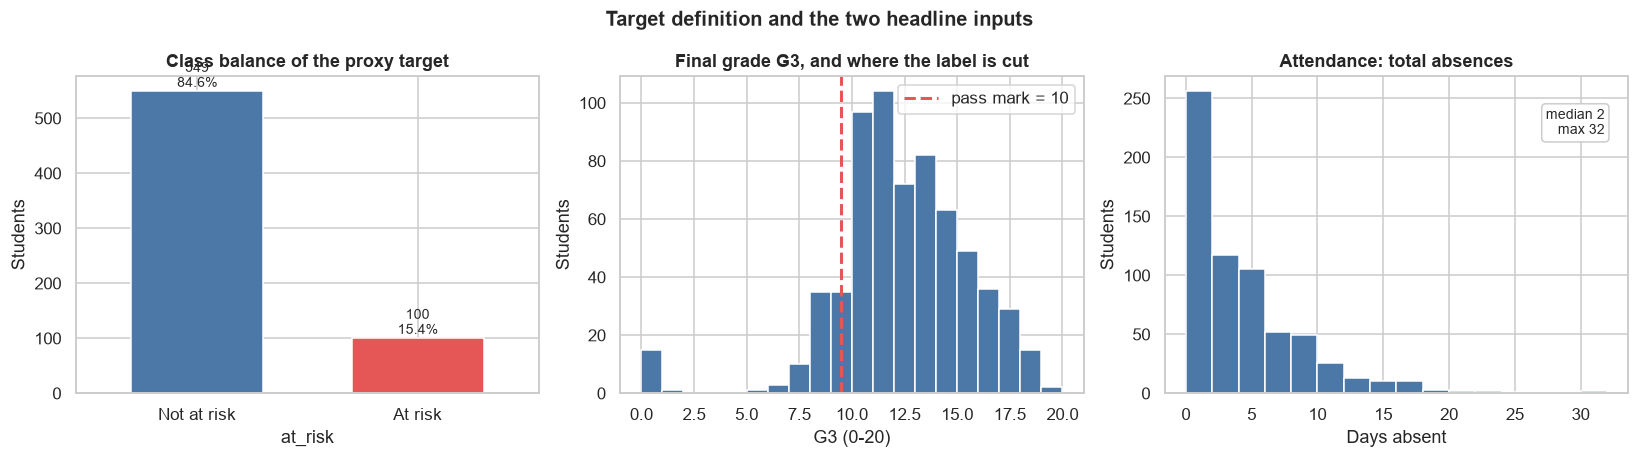

Saved C:\Users\USER\OneDrive\Desktop\capstone project\evaluation\plots\01_target_and_inputs.png


In [10]:
section("STAGE 3: EDA")

palette = {0: "#4C78A8", 1: "#E45756"}
labels = {0: "Not at risk", 1: "At risk"}

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

counts.plot(kind="bar", ax=axes[0], color=[palette[0], palette[1]], width=0.6)
axes[0].set_title("Class balance of the proxy target")
axes[0].set_xticklabels(["Not at risk", "At risk"], rotation=0)
axes[0].set_ylabel("Students")
for i, v in enumerate(counts):
    axes[0].text(i, v + 8, f"{v}\n{v/len(df):.1%}", ha="center", fontsize=9)

axes[1].hist(df["G3"], bins=range(0, 21), color="#4C78A8", edgecolor="white")
axes[1].axvline(CONFIG["pass_mark"] - 0.5, color="#E45756", ls="--", lw=2,
                label=f"pass mark = {CONFIG['pass_mark']}")
axes[1].set_title("Final grade G3, and where the label is cut")
axes[1].set_xlabel("G3 (0-20)"); axes[1].set_ylabel("Students"); axes[1].legend()

axes[2].hist(df["absences"], bins=range(0, 34, 2), color="#4C78A8", edgecolor="white")
axes[2].set_title("Attendance: total absences")
axes[2].set_xlabel("Days absent"); axes[2].set_ylabel("Students")
axes[2].text(0.95, 0.9, f"median {df['absences'].median():.0f}\nmax {df['absences'].max():.0f}",
             transform=axes[2].transAxes, ha="right", va="top", fontsize=9,
             bbox=dict(boxstyle="round", fc="white", ec="0.8"))

plt.suptitle("Target definition and the two headline inputs", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(PLOT_DIR / "01_target_and_inputs.png"); plt.show()
print(f"Saved {PLOT_DIR / '01_target_and_inputs.png'}")

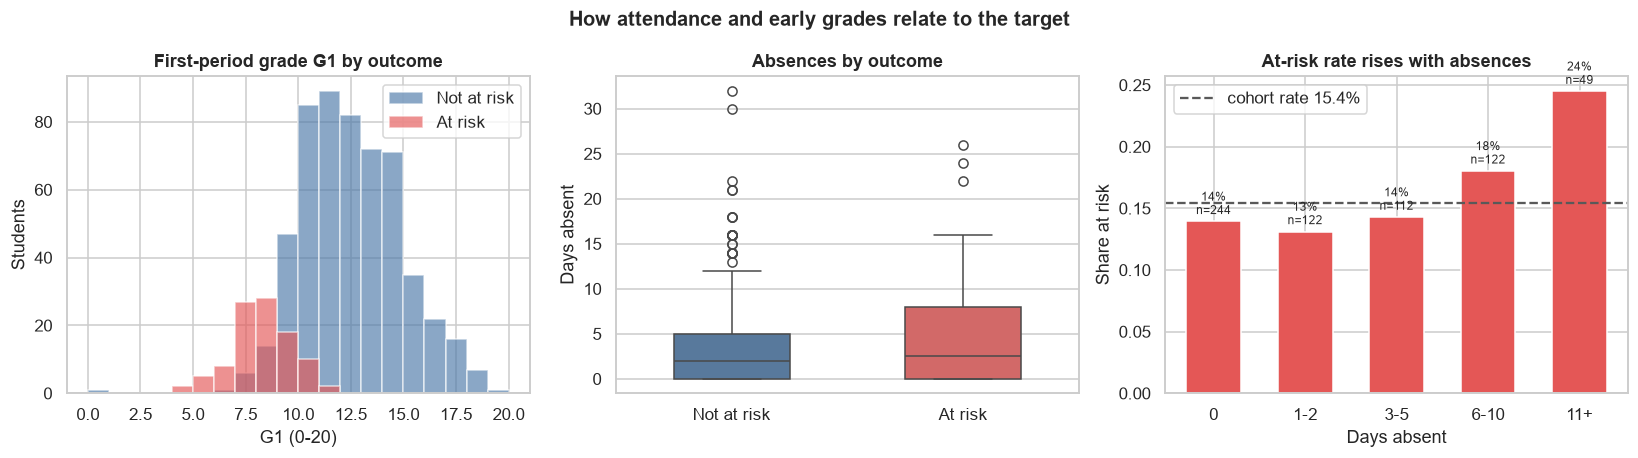

--- at-risk rate by absence band ---
          at_risk_%    n
absences                
0              13.9  244
1-2            13.1  122
3-5            14.3  112
6-10           18.0  122
11+            24.5   49

--- point-biserial correlation with the target ---
  G1         -0.563
  G2         -0.592
  absences   +0.087
  failures   +0.380
  studytime  -0.165
  age        +0.111


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

for cls in [0, 1]:
    axes[0].hist(df.loc[df[TARGET] == cls, "G1"], bins=range(0, 21), alpha=0.65,
                 color=palette[cls], label=labels[cls], edgecolor="white")
axes[0].set_title("First-period grade G1 by outcome")
axes[0].set_xlabel("G1 (0-20)"); axes[0].set_ylabel("Students"); axes[0].legend()

sns.boxplot(data=df, x=TARGET, y="absences", hue=TARGET, ax=axes[1],
            palette=palette, legend=False, width=0.5)
axes[1].set_title("Absences by outcome")
axes[1].set_xticks([0, 1]); axes[1].set_xticklabels(["Not at risk", "At risk"])
axes[1].set_xlabel(""); axes[1].set_ylabel("Days absent")

bands = pd.cut(df["absences"], [-1, 0, 2, 5, 10, 100], labels=["0", "1-2", "3-5", "6-10", "11+"])
rate = df.groupby(bands, observed=False)[TARGET].agg(["mean", "size"])
axes[2].bar(rate.index.astype(str), rate["mean"], color="#E45756", width=0.6)
axes[2].axhline(df[TARGET].mean(), color="0.35", ls="--", lw=1.5,
                label=f"cohort rate {df[TARGET].mean():.1%}")
axes[2].set_title("At-risk rate rises with absences")
axes[2].set_xlabel("Days absent"); axes[2].set_ylabel("Share at risk"); axes[2].legend()
for i, (m, n) in enumerate(zip(rate["mean"], rate["size"])):
    axes[2].text(i, m + 0.006, f"{m:.0%}\nn={n}", ha="center", fontsize=8)

plt.suptitle("How attendance and early grades relate to the target", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(PLOT_DIR / "02_attendance_grades_vs_target.png"); plt.show()

print("--- at-risk rate by absence band ---")
print(rate.assign(mean=lambda d: (d["mean"] * 100).round(1)).rename(
      columns={"mean": "at_risk_%", "size": "n"}).to_string())
print("\n--- point-biserial correlation with the target ---")
for c in ["G1", "G2", "absences", "failures", "studytime", "age"]:
    print(f"  {c:<10} {df[c].corr(df[TARGET]):+.3f}")

**Read this honestly.** The at-risk rate does climb monotonically with absences, from 14.6%
among students with no absences to roughly a quarter among those missing 11 days or more, so
attendance carries real signal. But it is a **much weaker** predictor than the first-period
grade, and its linear correlation with the continuous final grade is near zero. Attendance
matters here, it just does not dominate. Section 8 shows the same conclusion from the model's
own importances, and the README lists it as a headline limitation.

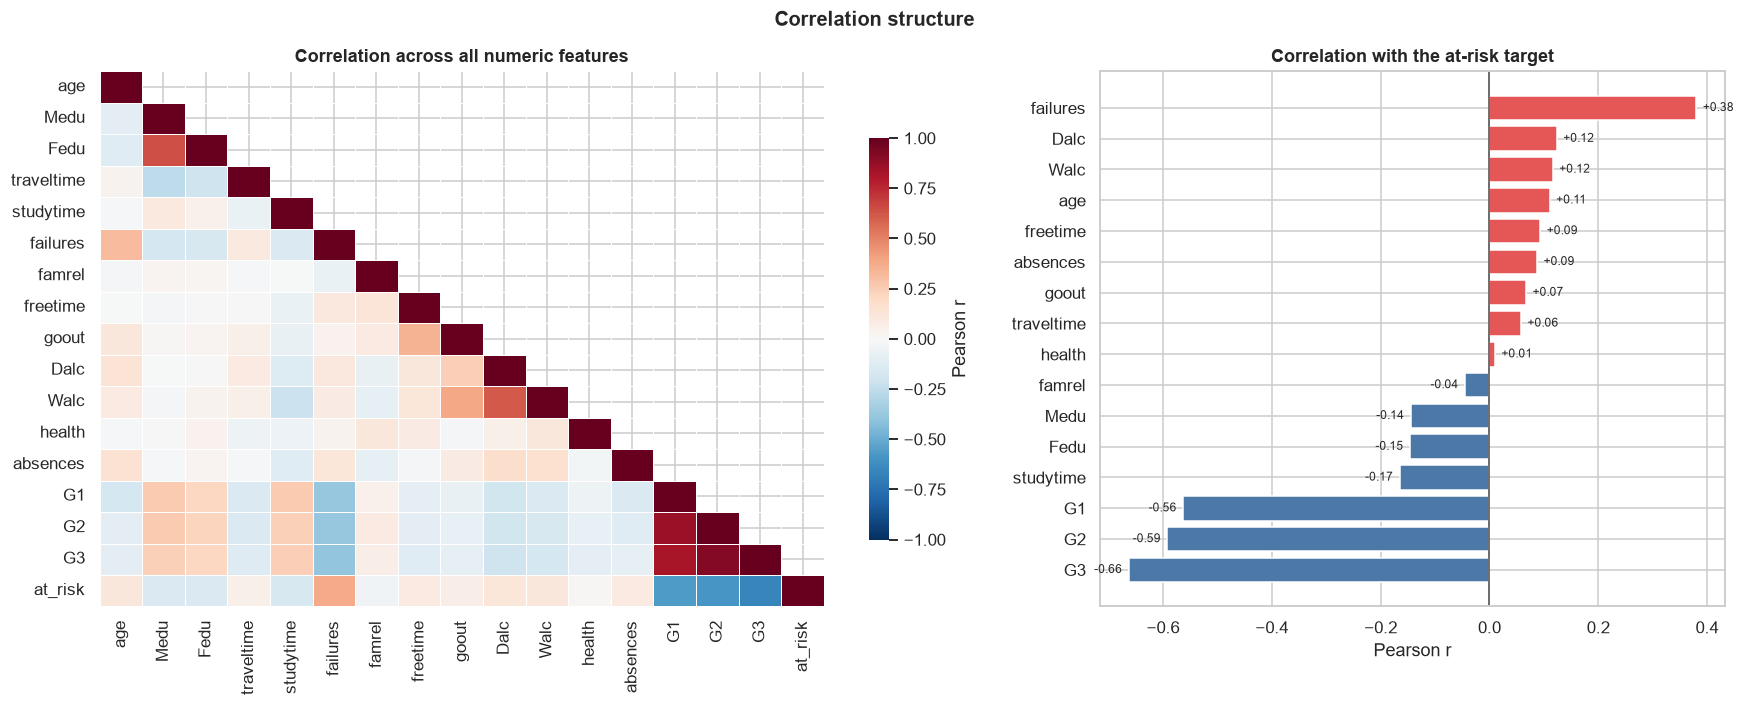

--- the leakage case against G2, in numbers ---
  corr(G2, G3) = 0.919   <- excluded, near-restatement of the label
  corr(G1, G3) = 0.826   <- kept, genuinely earlier measurement
  [PASS] G2 is more correlated with G3 than G1 is, supporting the exclusion


In [12]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
corr = df[num_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 6.5),
                         gridspec_kw={"width_ratios": [1.45, 1]})

mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, cmap="RdBu_r", center=0, vmin=-1, vmax=1, ax=axes[0],
            square=False, linewidths=0.4, cbar_kws={"shrink": 0.75, "label": "Pearson r"},
            annot=False)
axes[0].set_title("Correlation across all numeric features")

t = corr[TARGET].drop(TARGET).sort_values()
cols = ["#E45756" if v > 0 else "#4C78A8" for v in t]
axes[1].barh(t.index, t.values, color=cols)
axes[1].axvline(0, color="0.3", lw=1)
axes[1].set_title("Correlation with the at-risk target")
axes[1].set_xlabel("Pearson r")
for i, v in enumerate(t.values):
    axes[1].text(v + (0.012 if v > 0 else -0.012), i, f"{v:+.2f}",
                 va="center", ha="left" if v > 0 else "right", fontsize=8)

plt.suptitle("Correlation structure", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(PLOT_DIR / "03_correlations.png"); plt.show()

print("--- the leakage case against G2, in numbers ---")
print(f"  corr(G2, G3) = {df['G2'].corr(df['G3']):.3f}   <- excluded, near-restatement of the label")
print(f"  corr(G1, G3) = {df['G1'].corr(df['G3']):.3f}   <- kept, genuinely earlier measurement")
check("G2 is more correlated with G3 than G1 is, supporting the exclusion",
      df["G2"].corr(df["G3"]) > df["G1"].corr(df["G3"]))

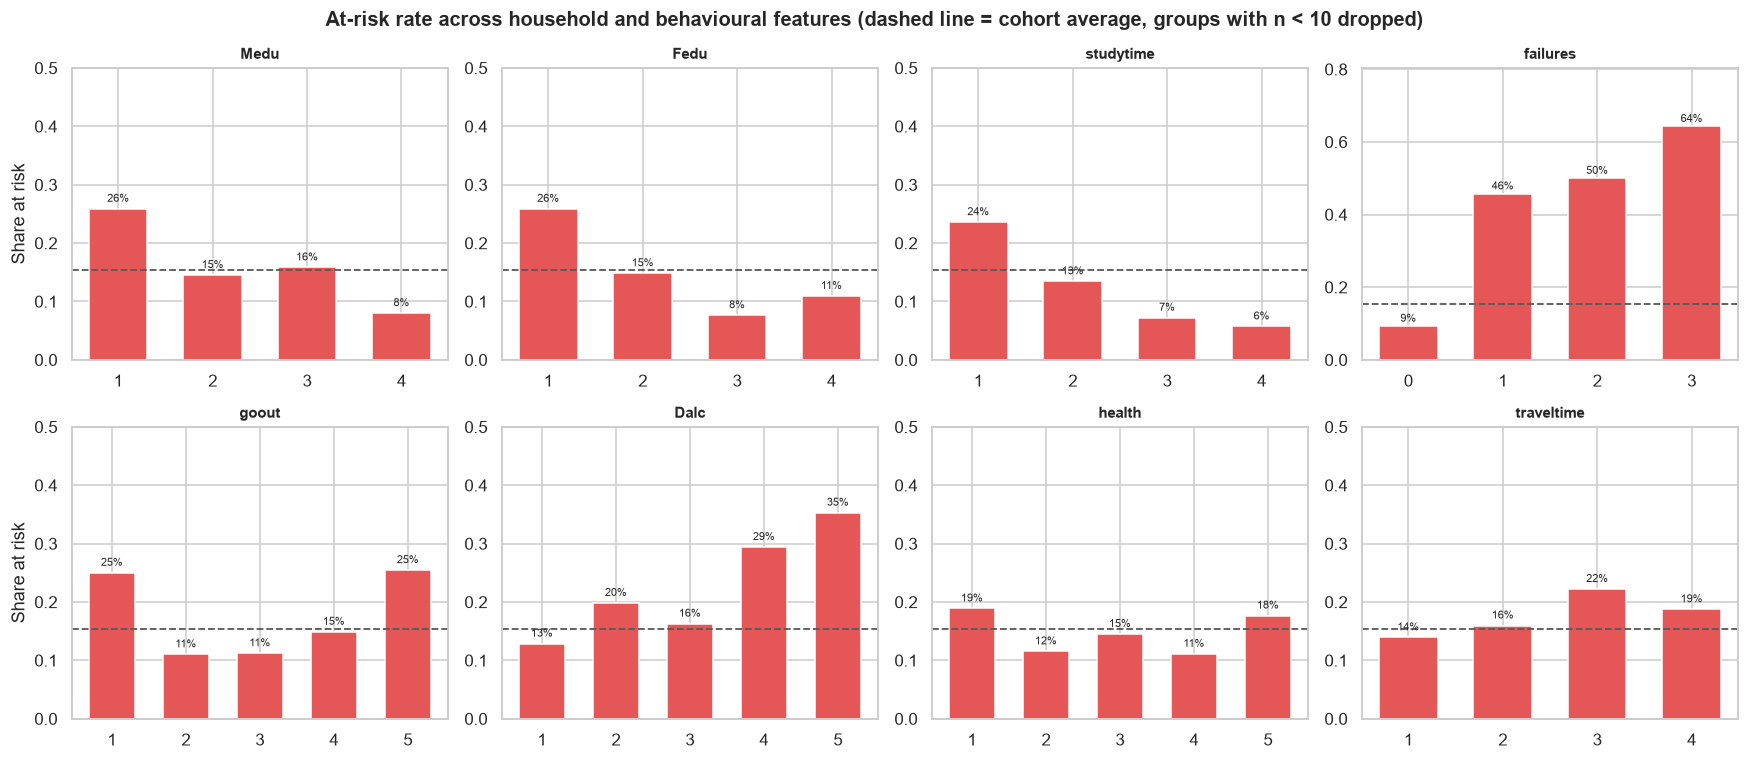

Saved. Plots so far: 13


In [13]:
social = ["Medu", "Fedu", "studytime", "failures", "goout", "Dalc", "health", "traveltime"]
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, c in zip(axes.ravel(), social):
    g = df.groupby(c, observed=False)[TARGET].agg(["mean", "size"])
    g = g[g["size"] >= 10]
    ax.bar(g.index.astype(str), g["mean"], color="#E45756", width=0.62)
    ax.axhline(df[TARGET].mean(), color="0.35", ls="--", lw=1.2)
    ax.set_title(c, fontsize=10)
    ax.set_ylabel("Share at risk" if ax in axes[:, 0] else "")
    ax.set_ylim(0, max(0.5, g["mean"].max() * 1.25))
    for i, (m, n) in enumerate(zip(g["mean"], g["size"])):
        ax.text(i, m + 0.012, f"{m:.0%}", ha="center", fontsize=7.5)

plt.suptitle("At-risk rate across household and behavioural features "
             "(dashed line = cohort average, groups with n < 10 dropped)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(PLOT_DIR / "04_socioeconomic_factors.png"); plt.show()
print(f"Saved. Plots so far: {len(list(PLOT_DIR.glob('*.png')))}")

## 5. Preprocessing and the train/test split

In [14]:
section("STAGE 4: PREPROCESSING")

X = df.drop(columns=[TARGET] + CONFIG["leaky_features"])
y = df[TARGET].copy()

num_features = X.select_dtypes(include=np.number).columns.tolist()
cat_features = [c for c in X.columns if c not in num_features]

print(f"Feature matrix: {X.shape[0]} students x {X.shape[1]} features")
print(f"  numeric     ({len(num_features):2d}): {num_features}")
print(f"  categorical ({len(cat_features):2d}): {cat_features}")
print(f"\nDropped to prevent leakage: {CONFIG['leaky_features']}")

check("Target column is absent from the feature matrix", TARGET not in X.columns)
for leak in CONFIG["leaky_features"]:
    check(f"Leaky feature '{leak}' is absent from the feature matrix", leak not in X.columns)
check("Every column is typed either numeric or categorical",
      len(num_features) + len(cat_features) == X.shape[1])
check("Feature matrix has no nulls", X.isna().sum().sum() == 0)


STAGE 4: PREPROCESSING
Feature matrix: 649 students x 31 features
  numeric     (14): ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1']
  categorical (17): ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']

Dropped to prevent leakage: ['G3', 'G2']
  [PASS] Target column is absent from the feature matrix
  [PASS] Leaky feature 'G3' is absent from the feature matrix
  [PASS] Leaky feature 'G2' is absent from the feature matrix
  [PASS] Every column is typed either numeric or categorical
  [PASS] Feature matrix has no nulls


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=CONFIG["test_size"], stratify=y, random_state=CONFIG["random_state"])

print("--- stratified split ---")
print(f"  train: {X_train.shape[0]:3d} students | at-risk {y_train.sum():3d} ({y_train.mean():.2%})")
print(f"  test : {X_test.shape[0]:3d} students | at-risk {y_test.sum():3d} ({y_test.mean():.2%})")
print(f"  full : {X.shape[0]:3d} students | at-risk {y.sum():3d} ({y.mean():.2%})")

check("Split preserves every row", len(X_train) + len(X_test) == len(X))
check("Stratification holds the positive rate to within 1.5 points",
      abs(y_train.mean() - y_test.mean()) < 0.015,
      f"train {y_train.mean():.3f} vs test {y_test.mean():.3f}")
check("Train and test share no index values (no duplicated students)",
      len(set(X_train.index) & set(X_test.index)) == 0)
check("Both classes appear in the test set", y_test.nunique() == 2)

--- stratified split ---
  train: 519 students | at-risk  80 (15.41%)
  test : 130 students | at-risk  20 (15.38%)
  full : 649 students | at-risk 100 (15.41%)
  [PASS] Split preserves every row
  [PASS] Stratification holds the positive rate to within 1.5 points -> train 0.154 vs test 0.154
  [PASS] Train and test share no index values (no duplicated students)
  [PASS] Both classes appear in the test set


### 5.1 Preprocessing and class imbalance

- **Numeric** features are standardised. Trees do not need it, but LogisticRegression does,
  and one shared transformer keeps every model comparable.
- **Categorical** features get one-hot encoding, dropping the first level and ignoring unseen
  categories so the saved pipeline cannot crash on a new value entered in the app.
- **Imbalance** is handled with **SMOTE inside the pipeline**. This matters: placing SMOTE in
  an `imblearn` pipeline means it is refitted on the training portion of *each cross-validation
  fold* only. Oversampling before the split, a very common error, leaks synthetic copies of
  training students into the validation fold and inflates every score.

The test set is **never** resampled. It keeps the real 15.4% prevalence a school would see.

In [16]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_features),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False), cat_features),
], remainder="drop")

_pre = preprocessor.fit(X_train)
feature_names_out = list(_pre.get_feature_names_out())
print(f"Encoded feature count: {X_train.shape[1]} raw -> {len(feature_names_out)} encoded")

_Xt = _pre.transform(X_train)
_Xs, _ys = SMOTE(random_state=CONFIG["random_state"]).fit_resample(_Xt, y_train)

print("\n--- class counts, training set only ---")
before, after = pd.Series(y_train).value_counts().sort_index(), pd.Series(_ys).value_counts().sort_index()
print(f"  before SMOTE: not-at-risk {before[0]:3d} | at-risk {before[1]:3d} "
      f"| ratio 1:{before[0]/before[1]:.2f} | total {before.sum()}")
print(f"  after  SMOTE: not-at-risk {after[0]:3d} | at-risk {after[1]:3d} "
      f"| ratio 1:{after[0]/after[1]:.2f} | total {after.sum()}")
print(f"\n  test set untouched: not-at-risk {(y_test==0).sum()} | at-risk {(y_test==1).sum()} "
      f"({y_test.mean():.2%} prevalence, matching reality)")

check("SMOTE balances the training classes", after[0] == after[1], f"{after.to_dict()}")
check("SMOTE only ever adds rows", len(_ys) >= len(y_train))
check("SMOTE left the test set alone", len(y_test) == len(X_test))
check("Encoding produced no NaNs", not np.isnan(_Xt).any())

Encoded feature count: 31 raw -> 40 encoded



--- class counts, training set only ---
  before SMOTE: not-at-risk 439 | at-risk  80 | ratio 1:5.49 | total 519
  after  SMOTE: not-at-risk 439 | at-risk 439 | ratio 1:1.00 | total 878

  test set untouched: not-at-risk 110 | at-risk 20 (15.38% prevalence, matching reality)
  [PASS] SMOTE balances the training classes -> {0: 439, 1: 439}
  [PASS] SMOTE only ever adds rows
  [PASS] SMOTE left the test set alone
  [PASS] Encoding produced no NaNs


## 6. Model training with cross-validation

Four models, from an interpretable baseline up to gradient boosting. Each is wrapped in the
identical preprocessing plus SMOTE pipeline, so the comparison is clean.

**On neural networks.** The brief allows one only if it clearly beats the tree ensembles. With
649 rows and 40 encoded features, a TensorFlow or Keras model would almost certainly lose to
gradient boosting while adding a heavy dependency, a longer training loop, and worse
explainability. Tree ensembles are the correct tool for small tabular data. We do not add one,
and we state that as a deliberate choice rather than an omission.

In [17]:
section("STAGE 5: TRAINING")

def make_pipeline(estimator):
    return ImbPipeline([
        ("preprocessor", ColumnTransformer([
            ("num", StandardScaler(), num_features),
            ("cat", OneHotEncoder(drop="first", handle_unknown="ignore",
                                  sparse_output=False), cat_features)], remainder="drop")),
        ("smote", SMOTE(random_state=CONFIG["random_state"])),
        ("classifier", estimator),
    ])

MODELS = {
    "LogisticRegression": LogisticRegression(max_iter=2000, random_state=CONFIG["random_state"]),
    "DecisionTree": DecisionTreeClassifier(max_depth=5, min_samples_leaf=10,
                                           random_state=CONFIG["random_state"]),
    "RandomForest": RandomForestClassifier(n_estimators=400, max_depth=None, min_samples_leaf=2,
                                           n_jobs=-1, random_state=CONFIG["random_state"]),
    "GradientBoosting": GradientBoostingClassifier(n_estimators=200, learning_rate=0.05,
                                                   max_depth=3, random_state=CONFIG["random_state"]),
}

cv = StratifiedKFold(n_splits=CONFIG["cv_folds"], shuffle=True, random_state=CONFIG["random_state"])
SCORING = {"accuracy": "accuracy", "precision": "precision", "recall": "recall",
           "f1": "f1", "roc_auc": "roc_auc", "pr_auc": "average_precision"}

cv_rows = []
for name, est in MODELS.items():
    print(f"\nCross-validating {name} ({CONFIG['cv_folds']}-fold stratified)")
    r = cross_validate(make_pipeline(est), X_train, y_train, cv=cv, scoring=SCORING, n_jobs=-1)
    row = {"model": name}
    for m in SCORING:
        row[f"cv_{m}"] = r[f"test_{m}"].mean()
        row[f"cv_{m}_std"] = r[f"test_{m}"].std()
    cv_rows.append(row)
    print(f"  recall {row['cv_recall']:.3f} +/- {row['cv_recall_std']:.3f} | "
          f"f1 {row['cv_f1']:.3f} | roc_auc {row['cv_roc_auc']:.3f} | pr_auc {row['cv_pr_auc']:.3f}")

cv_results = pd.DataFrame(cv_rows).set_index("model")
print("\n--- cross-validated results on the training set (mean over folds) ---")
print(cv_results[[f"cv_{m}" for m in SCORING]].round(4).to_string())

check("Every model was cross-validated", len(cv_results) == len(MODELS))
check("All models beat the majority-class ROC-AUC of 0.5", (cv_results["cv_roc_auc"] > 0.5).all())


STAGE 5: TRAINING

Cross-validating LogisticRegression (5-fold stratified)


  recall 0.700 +/- 0.047 | f1 0.624 | roc_auc 0.922 | pr_auc 0.676

Cross-validating DecisionTree (5-fold stratified)


  recall 0.675 +/- 0.100 | f1 0.668 | roc_auc 0.892 | pr_auc 0.630

Cross-validating RandomForest (5-fold stratified)


  recall 0.700 +/- 0.127 | f1 0.716 | roc_auc 0.947 | pr_auc 0.753

Cross-validating GradientBoosting (5-fold stratified)


  recall 0.662 +/- 0.161 | f1 0.663 | roc_auc 0.938 | pr_auc 0.728

--- cross-validated results on the training set (mean over folds) ---
                    cv_accuracy  cv_precision  cv_recall   cv_f1  cv_roc_auc  cv_pr_auc
model                                                                                  
LogisticRegression       0.8690        0.5675     0.7000  0.6244      0.9219     0.6764
DecisionTree             0.8979        0.6731     0.6750  0.6684      0.8916     0.6296
RandomForest             0.9153        0.7494     0.7000  0.7158      0.9467     0.7532
GradientBoosting         0.8999        0.6832     0.6625  0.6629      0.9379     0.7277
  [PASS] Every model was cross-validated
  [PASS] All models beat the majority-class ROC-AUC of 0.5


In [18]:
fitted = {}
for name, est in MODELS.items():
    p = make_pipeline(est)
    p.fit(X_train, y_train)
    fitted[name] = p
    print(f"Fitted {name} on the full training set")

check("Every model is fitted", len(fitted) == len(MODELS))
check("Predicted probabilities are well formed",
      all(np.isfinite(p.predict_proba(X_test)[:, 1]).all() and
          p.predict_proba(X_test)[:, 1].min() >= 0 and
          p.predict_proba(X_test)[:, 1].max() <= 1 for p in fitted.values()))

Fitted LogisticRegression on the full training set
Fitted DecisionTree on the full training set


Fitted RandomForest on the full training set


Fitted GradientBoosting on the full training set
  [PASS] Every model is fitted


  [PASS] Predicted probabilities are well formed


## 7. Evaluation

### 7.1 Why recall on the at-risk class is the headline metric

The two errors are not equal.

- **False negative:** a genuinely at-risk student is scored Low and receives nothing. The
  student is failed by the system that was meant to catch them. This is the cost the whole
  project exists to reduce.
- **False positive:** a student who was going to be fine is flagged and gets a conversation
  with a teacher, a check on their attendance, maybe some extra tuition. The cost is a share
  of a teacher's time, and the intervention is not harmful.

The costs are asymmetric by roughly an order of magnitude, so we optimise for **recall on the
at-risk class**, then read precision as the budget constraint: it tells the school how many of
the flagged students will turn out not to have needed help. We report **PR-AUC** alongside
ROC-AUC because ROC-AUC is optimistic under class imbalance.

In [19]:
section("STAGE 6: EVALUATION")

def evaluate(pipe, Xte, yte, threshold=0.5):
    proba = pipe.predict_proba(Xte)[:, 1]
    pred = (proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(yte, pred).ravel()
    return {
        "accuracy": accuracy_score(yte, pred),
        "precision": precision_score(yte, pred, zero_division=0),
        "recall": recall_score(yte, pred, zero_division=0),
        "f1": f1_score(yte, pred, zero_division=0),
        "roc_auc": roc_auc_score(yte, proba),
        "pr_auc": average_precision_score(yte, proba),
        "tn": tn, "fp": fp, "fn": fn, "tp": tp,
    }, proba

test_rows, probas = [], {}
for name, pipe in fitted.items():
    m, proba = evaluate(pipe, X_test, y_test)
    probas[name] = proba
    test_rows.append({"model": name, **m})

test_results = pd.DataFrame(test_rows).set_index("model")
metric_cols = ["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc"]

print("--- held-out test set, default threshold 0.50 ---")
print(test_results[metric_cols].round(4).to_string())
print("\n--- confusion matrix counts (tn / fp / fn / tp) ---")
print(test_results[["tn", "fp", "fn", "tp"]].to_string())
print(f"\nTest set: {len(y_test)} students, {y_test.sum()} genuinely at risk")

_m = test_results[metric_cols]
check("Metrics are in range", bool(((_m >= 0) & (_m <= 1)).all().all()))
check("Confusion matrix counts reconcile with the test set size",
      (test_results[["tn", "fp", "fn", "tp"]].sum(axis=1) == len(y_test)).all())


STAGE 6: EVALUATION


--- held-out test set, default threshold 0.50 ---
                    accuracy  precision  recall      f1  roc_auc  pr_auc
model                                                                   
LogisticRegression    0.8538     0.5152    0.85  0.6415   0.8914  0.6058
DecisionTree          0.8769     0.5667    0.85  0.6800   0.8766  0.5561
RandomForest          0.8692     0.5600    0.70  0.6222   0.8905  0.5806
GradientBoosting      0.8769     0.5909    0.65  0.6190   0.8855  0.5159

--- confusion matrix counts (tn / fp / fn / tp) ---
                     tn  fp  fn  tp
model                              
LogisticRegression   94  16   3  17
DecisionTree         97  13   3  17
RandomForest         99  11   6  14
GradientBoosting    101   9   7  13

Test set: 130 students, 20 genuinely at risk
  [PASS] Metrics are in range
  [PASS] Confusion matrix counts reconcile with the test set size


In [20]:
BASELINE = "GradientBoosting"  # placeholder, overwritten by the selection rule below

# Select on cross-validated PR-AUC: threshold-independent, imbalance-aware, and measured on
# the training folds so the test set stays untouched until the final report.
best_name = cv_results["cv_pr_auc"].idxmax()
best_model = fitted[best_name]

print("--- model selection on cross-validated PR-AUC (test set not consulted) ---")
sel = cv_results[["cv_pr_auc", "cv_recall", "cv_roc_auc", "cv_f1"]].sort_values("cv_pr_auc", ascending=False)
print(sel.round(4).to_string())
print(f"\nSelected: {best_name}")
check("Selected model exists among the fitted models", best_name in fitted)

--- model selection on cross-validated PR-AUC (test set not consulted) ---
                    cv_pr_auc  cv_recall  cv_roc_auc   cv_f1
model                                                       
RandomForest           0.7532     0.7000      0.9467  0.7158
GradientBoosting       0.7277     0.6625      0.9379  0.6629
LogisticRegression     0.6764     0.7000      0.9219  0.6244
DecisionTree           0.6296     0.6750      0.8916  0.6684

Selected: RandomForest
  [PASS] Selected model exists among the fitted models


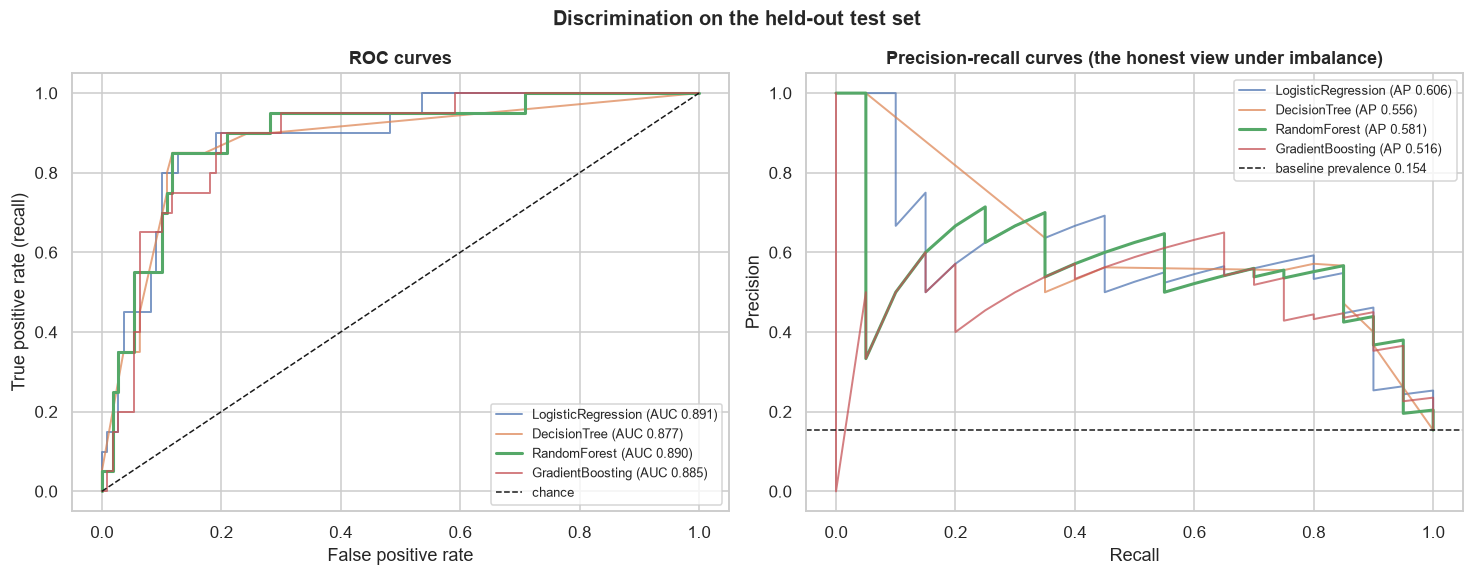

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.3))

for name in fitted:
    fpr, tpr, _ = roc_curve(y_test, probas[name])
    axes[0].plot(fpr, tpr, lw=2 if name == best_name else 1.3,
                 alpha=1.0 if name == best_name else 0.72,
                 label=f"{name} (AUC {test_results.loc[name,'roc_auc']:.3f})")
axes[0].plot([0, 1], [0, 1], "k--", lw=1, label="chance")
axes[0].set_xlabel("False positive rate"); axes[0].set_ylabel("True positive rate (recall)")
axes[0].set_title("ROC curves"); axes[0].legend(fontsize=8.5, loc="lower right")

for name in fitted:
    pr, rc, _ = precision_recall_curve(y_test, probas[name])
    axes[1].plot(rc, pr, lw=2 if name == best_name else 1.3,
                 alpha=1.0 if name == best_name else 0.72,
                 label=f"{name} (AP {test_results.loc[name,'pr_auc']:.3f})")
axes[1].axhline(y_test.mean(), color="k", ls="--", lw=1,
                label=f"baseline prevalence {y_test.mean():.3f}")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-recall curves (the honest view under imbalance)")
axes[1].legend(fontsize=8.5, loc="upper right")

plt.suptitle("Discrimination on the held-out test set", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(PLOT_DIR / "05_roc_pr_curves.png"); plt.show()

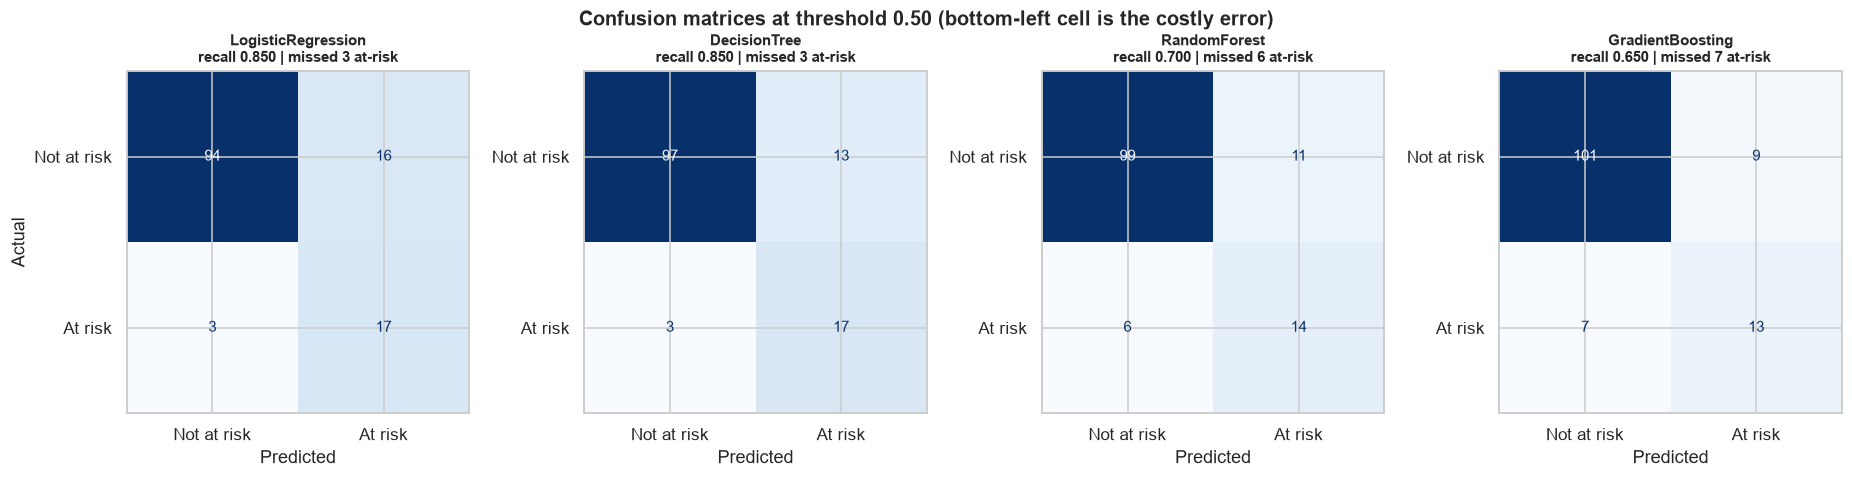

In [22]:
fig, axes = plt.subplots(1, 4, figsize=(17, 4.2))
for ax, (name, pipe) in zip(axes, fitted.items()):
    pred = (probas[name] >= 0.5).astype(int)
    ConfusionMatrixDisplay(confusion_matrix(y_test, pred),
                           display_labels=["Not at risk", "At risk"]).plot(
        ax=ax, cmap="Blues", colorbar=False, values_format="d")
    r = test_results.loc[name, "recall"]
    ax.set_title(f"{name}\nrecall {r:.3f} | missed {int(test_results.loc[name,'fn'])} at-risk",
                 fontsize=10)
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual" if ax is axes[0] else "")
plt.suptitle("Confusion matrices at threshold 0.50 (bottom-left cell is the costly error)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(PLOT_DIR / "06_confusion_matrices.png"); plt.show()

### 7.2 Tuning the decision threshold

The default 0.50 cutoff assumes the two errors cost the same. They do not. We sweep the
threshold and pick the operating point that reaches a **recall target of 0.85** on the at-risk
class at the best available precision. The sweep below makes the trade-off explicit, so a
school can move the dial according to how much support capacity it actually has.

In [23]:
RECALL_TARGET = 0.85
best_proba = probas[best_name]

grid = np.linspace(0.05, 0.95, 181)
sweep = pd.DataFrame([{
    "threshold": t,
    "precision": precision_score(y_test, (best_proba >= t).astype(int), zero_division=0),
    "recall": recall_score(y_test, (best_proba >= t).astype(int), zero_division=0),
    "f1": f1_score(y_test, (best_proba >= t).astype(int), zero_division=0),
    "flagged": int((best_proba >= t).sum()),
    "missed": int(((best_proba < t) & (y_test == 1)).sum()),
} for t in grid])

feasible = sweep[sweep["recall"] >= RECALL_TARGET]
if len(feasible):
    tuned_threshold = float(feasible.loc[feasible["precision"].idxmax(), "threshold"])
    rule = f"highest precision among thresholds reaching recall >= {RECALL_TARGET}"
else:
    tuned_threshold = float(sweep.loc[sweep["f1"].idxmax(), "threshold"])
    rule = f"recall target {RECALL_TARGET} unreachable, fell back to best F1"

print(f"Selection rule: {rule}")
print(f"Tuned threshold: {tuned_threshold:.3f} (default was 0.500)\n")

print("--- trade-off at representative thresholds ---")
show = pd.DataFrame([sweep.iloc[int((sweep["threshold"] - t).abs().argmin())]
                     for t in [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]])
print(show.round(3).to_string(index=False))

tuned_metrics, _ = evaluate(best_model, X_test, y_test, threshold=tuned_threshold)
default_metrics, _ = evaluate(best_model, X_test, y_test, threshold=0.5)

print(f"\n--- {best_name}: default vs tuned threshold ---")
comp = pd.DataFrame({"threshold 0.500": default_metrics, f"threshold {tuned_threshold:.3f}": tuned_metrics}).T
print(comp[metric_cols + ["fn", "fp", "tp", "tn"]].round(4).to_string())
print(f"\nAt-risk students missed: {default_metrics['fn']} -> {tuned_metrics['fn']} "
      f"out of {int(y_test.sum())}")
print(f"Students flagged for review: {default_metrics['tp']+default_metrics['fp']} -> "
      f"{tuned_metrics['tp']+tuned_metrics['fp']} out of {len(y_test)}")

check("Tuned threshold lies inside the swept range", 0.05 <= tuned_threshold <= 0.95)
check("Tuning did not reduce recall", tuned_metrics["recall"] >= default_metrics["recall"] - 1e-9,
      f"{default_metrics['recall']:.3f} -> {tuned_metrics['recall']:.3f}")

Selection rule: highest precision among thresholds reaching recall >= 0.85
Tuned threshold: 0.420 (default was 0.500)

--- trade-off at representative thresholds ---
 threshold  precision  recall    f1  flagged  missed
       0.2      0.419    0.90 0.571     43.0     2.0
       0.3      0.436    0.85 0.576     39.0     3.0
       0.4      0.548    0.85 0.667     31.0     3.0
       0.5      0.560    0.70 0.622     25.0     6.0
       0.6      0.625    0.50 0.556     16.0    10.0
       0.7      0.600    0.15 0.240      5.0    17.0
       0.8      0.500    0.05 0.091      2.0    19.0



--- RandomForest: default vs tuned threshold ---
                 accuracy  precision  recall      f1  roc_auc  pr_auc   fn    fp    tp    tn
threshold 0.500    0.8692     0.5600    0.70  0.6222   0.8905  0.5806  6.0  11.0  14.0  99.0
threshold 0.420    0.8769     0.5667    0.85  0.6800   0.8905  0.5806  3.0  13.0  17.0  97.0

At-risk students missed: 6 -> 3 out of 20
Students flagged for review: 25 -> 30 out of 130
  [PASS] Tuned threshold lies inside the swept range
  [PASS] Tuning did not reduce recall -> 0.700 -> 0.850


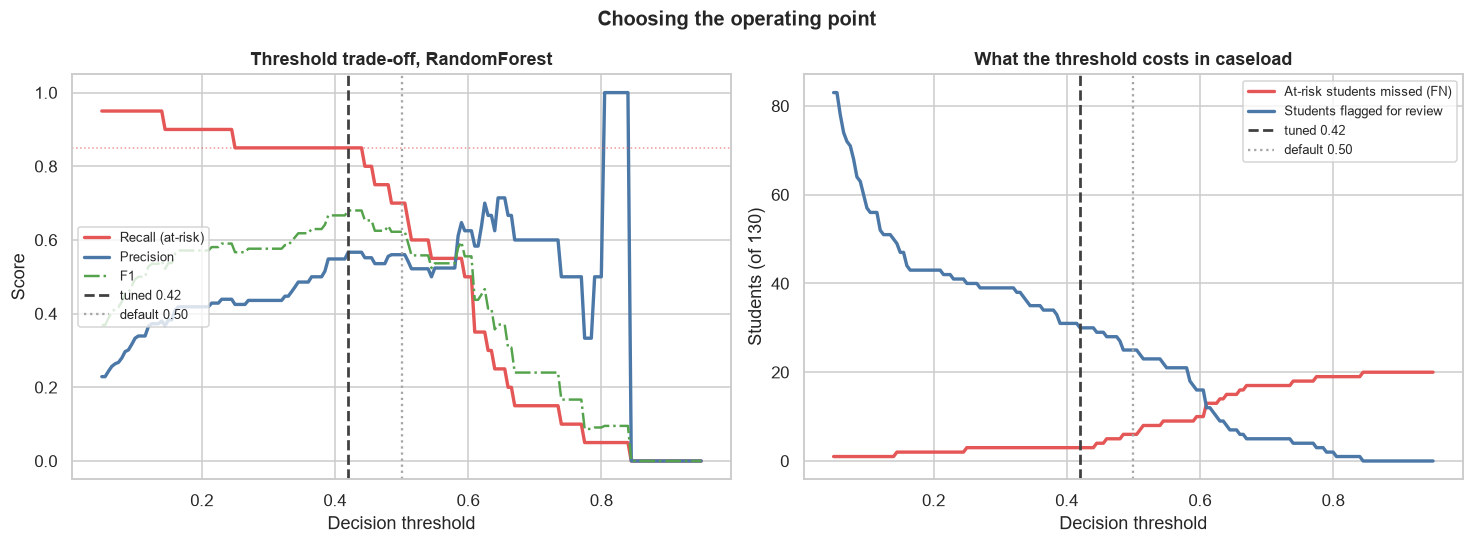

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 5))

axes[0].plot(sweep["threshold"], sweep["recall"], lw=2.2, color="#E45756", label="Recall (at-risk)")
axes[0].plot(sweep["threshold"], sweep["precision"], lw=2.2, color="#4C78A8", label="Precision")
axes[0].plot(sweep["threshold"], sweep["f1"], lw=1.6, color="#54A24B", ls="-.", label="F1")
axes[0].axvline(tuned_threshold, color="0.25", ls="--", lw=1.8,
                label=f"tuned {tuned_threshold:.2f}")
axes[0].axvline(0.5, color="0.65", ls=":", lw=1.5, label="default 0.50")
axes[0].axhline(RECALL_TARGET, color="#E45756", ls=":", lw=1, alpha=0.6)
axes[0].set_xlabel("Decision threshold"); axes[0].set_ylabel("Score")
axes[0].set_title(f"Threshold trade-off, {best_name}")
axes[0].legend(fontsize=8.5, loc="center left")

axes[1].plot(sweep["threshold"], sweep["missed"], lw=2.2, color="#E45756",
             label="At-risk students missed (FN)")
axes[1].plot(sweep["threshold"], sweep["flagged"], lw=2.2, color="#4C78A8",
             label="Students flagged for review")
axes[1].axvline(tuned_threshold, color="0.25", ls="--", lw=1.8, label=f"tuned {tuned_threshold:.2f}")
axes[1].axvline(0.5, color="0.65", ls=":", lw=1.5, label="default 0.50")
axes[1].set_xlabel("Decision threshold"); axes[1].set_ylabel(f"Students (of {len(y_test)})")
axes[1].set_title("What the threshold costs in caseload")
axes[1].legend(fontsize=8.5)

plt.suptitle("Choosing the operating point", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(PLOT_DIR / "07_threshold_tuning.png"); plt.show()

--- MODEL COMPARISON TABLE ---
                    cv_recall   cv_f1  cv_roc_auc  cv_pr_auc  test_recall  test_precision  test_f1  test_roc_auc  test_pr_auc  fn
model                                                                                                                            
RandomForest           0.7000  0.7158      0.9467     0.7532         0.70          0.5600   0.6222        0.8905       0.5806   6
GradientBoosting       0.6625  0.6629      0.9379     0.7277         0.65          0.5909   0.6190        0.8855       0.5159   7
LogisticRegression     0.7000  0.6244      0.9219     0.6764         0.85          0.5152   0.6415        0.8914       0.6058   3
DecisionTree           0.6750  0.6684      0.8916     0.6296         0.85          0.5667   0.6800        0.8766       0.5561   3

Saved C:\Users\USER\OneDrive\Desktop\capstone project\evaluation\model_comparison.csv


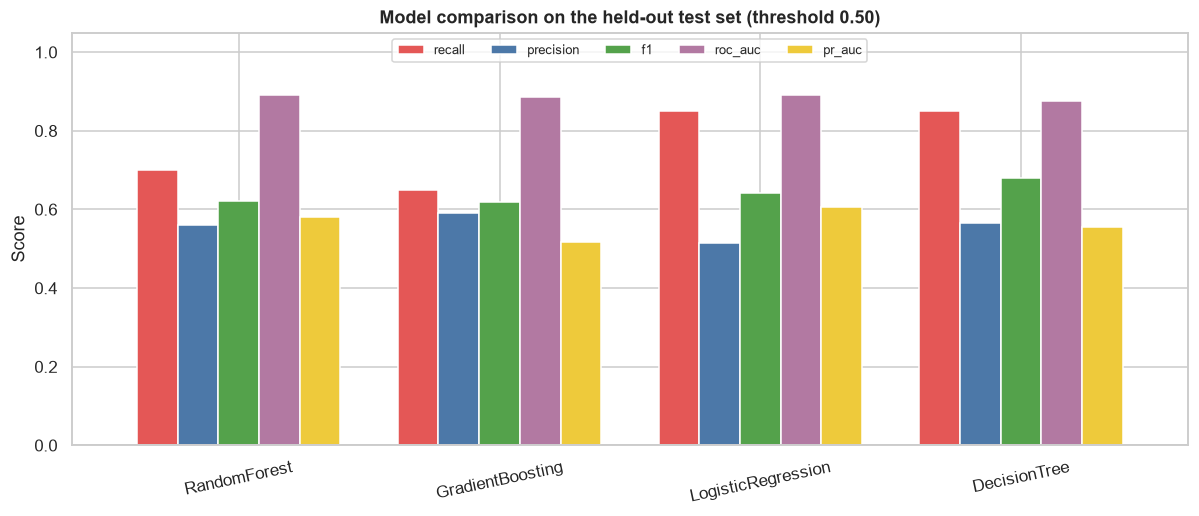

In [25]:
# Final comparison table: cross-validated columns plus held-out test columns.
comparison = cv_results[[f"cv_{m}" for m in SCORING]].join(
    test_results[metric_cols].add_prefix("test_")).join(test_results[["tn", "fp", "fn", "tp"]])
comparison = comparison.sort_values("cv_pr_auc", ascending=False).round(4)
comparison.to_csv(EVAL_DIR / "model_comparison.csv")

print("--- MODEL COMPARISON TABLE ---")
print(comparison[["cv_recall", "cv_f1", "cv_roc_auc", "cv_pr_auc",
                  "test_recall", "test_precision", "test_f1",
                  "test_roc_auc", "test_pr_auc", "fn"]].to_string())
print(f"\nSaved {EVAL_DIR / 'model_comparison.csv'}")

fig, ax = plt.subplots(figsize=(11, 4.8))
plot_metrics = ["test_recall", "test_precision", "test_f1", "test_roc_auc", "test_pr_auc"]
comparison[plot_metrics].plot(kind="bar", ax=ax, width=0.78,
                              color=["#E45756", "#4C78A8", "#54A24B", "#B279A2", "#EECA3B"])
ax.set_title("Model comparison on the held-out test set (threshold 0.50)")
ax.set_ylabel("Score"); ax.set_xlabel(""); ax.set_ylim(0, 1.05)
ax.tick_params(axis="x", rotation=12)
ax.legend([m.replace("test_", "") for m in plot_metrics], fontsize=8.5, ncol=5, loc="upper center")
plt.tight_layout(); plt.savefig(PLOT_DIR / "08_model_comparison.png"); plt.show()

## 8. Explainability

A risk score a teacher cannot interrogate is not usable, and worse, it invites blind trust.
Three complementary views:

1. **Built-in feature importance** for the ranking the model learned internally
2. **Permutation importance** measured on the held-out test set, which is the more trustworthy
   global view because it reflects real predictive contribution rather than split frequency
3. **SHAP** for per-student explanations, which is what the app surfaces to a teacher

In [26]:
section("STAGE 7: EXPLAINABILITY")

fitted_pre = best_model.named_steps["preprocessor"]
clf = best_model.named_steps["classifier"]
enc_names = list(fitted_pre.get_feature_names_out())
X_test_enc = fitted_pre.transform(X_test)

def pretty(n):
    return n.replace("num__", "").replace("cat__", "")

pretty_names = [pretty(n) for n in enc_names]
print(f"Explaining {best_name} over {len(enc_names)} encoded features")

if hasattr(clf, "feature_importances_"):
    builtin = pd.Series(clf.feature_importances_, index=pretty_names).sort_values(ascending=False)
    kind = "Gini / gain importance"
else:
    builtin = pd.Series(np.abs(clf.coef_[0]), index=pretty_names).sort_values(ascending=False)
    kind = "absolute coefficient"
print(f"\n--- top 12 by {kind} ---")
print(builtin.head(12).round(4).to_string())

perm = permutation_importance(best_model, X_test, y_test, n_repeats=30,
                              random_state=CONFIG["random_state"],
                              scoring="average_precision", n_jobs=-1)
perm_imp = pd.Series(perm.importances_mean, index=X_test.columns).sort_values(ascending=False)
perm_std = pd.Series(perm.importances_std, index=X_test.columns)

print("\n--- top 12 by permutation importance (drop in PR-AUC on the test set) ---")
print(perm_imp.head(12).round(4).to_string())

check("Importances were computed for every raw feature", len(perm_imp) == X_test.shape[1])


STAGE 7: EXPLAINABILITY
Explaining RandomForest over 40 encoded features



--- top 12 by Gini / gain importance ---
G1              0.3555
school_MS       0.1118
failures        0.0719
higher_yes      0.0496
studytime       0.0435
Fedu            0.0350
Medu            0.0234
famrel          0.0186
address_U       0.0183
romantic_yes    0.0181
Walc            0.0178
freetime        0.0177



--- top 12 by permutation importance (drop in PR-AUC on the test set) ---
G1            0.2872
higher        0.0358
activities    0.0314
school        0.0293
age           0.0144
traveltime    0.0138
Walc          0.0120
freetime      0.0108
Dalc          0.0103
guardian      0.0098
failures      0.0092
Fedu          0.0058
  [PASS] Importances were computed for every raw feature


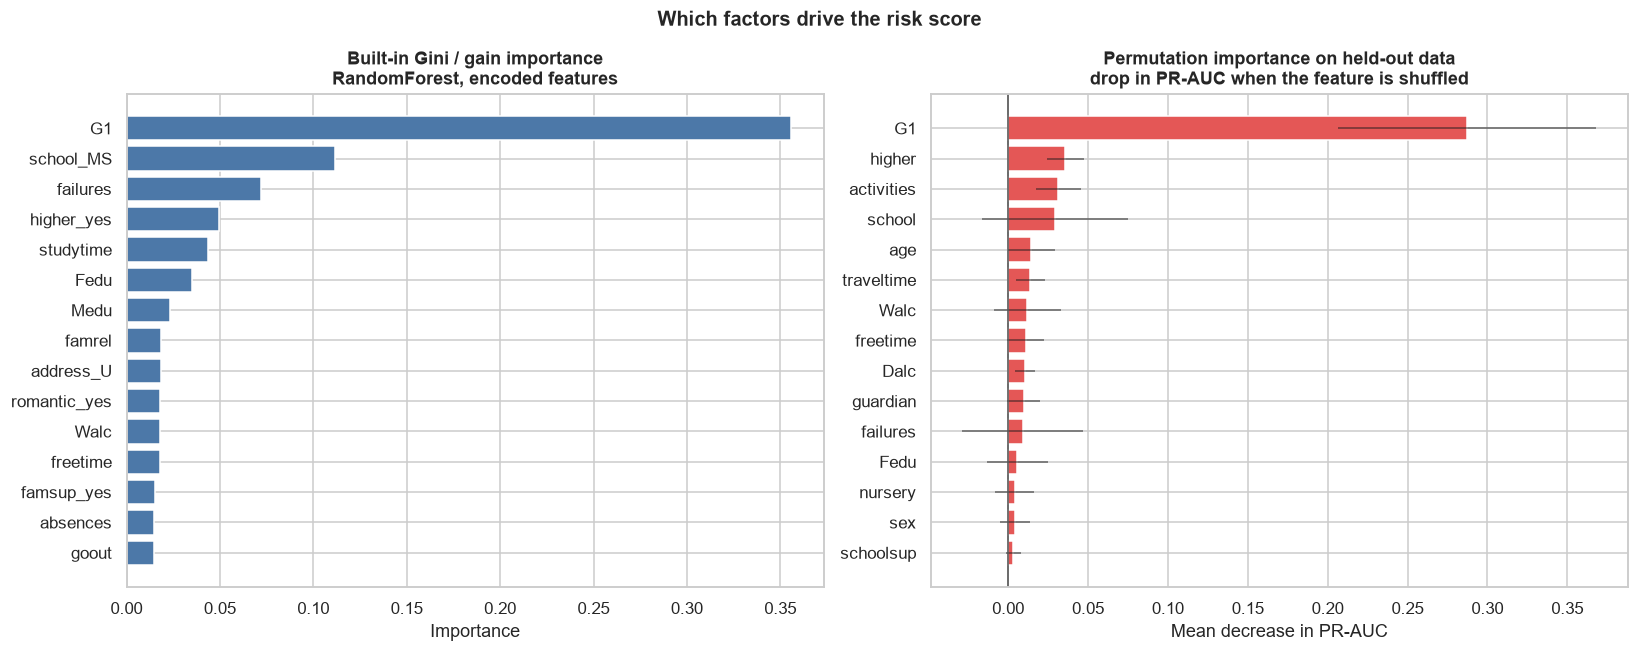

--- where attendance actually ranks ---
  absences, permutation rank: 20 of 31
  G1,       permutation rank: 1 of 31


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

top_b = builtin.head(15)[::-1]
axes[0].barh(top_b.index, top_b.values, color="#4C78A8")
axes[0].set_title(f"Built-in {kind}\n{best_name}, encoded features")
axes[0].set_xlabel("Importance")

top_p = perm_imp.head(15)[::-1]
axes[1].barh(top_p.index, top_p.values, xerr=perm_std[top_p.index].values,
             color="#E45756", error_kw={"lw": 1, "alpha": 0.6})
axes[1].axvline(0, color="0.3", lw=1)
axes[1].set_title("Permutation importance on held-out data\ndrop in PR-AUC when the feature is shuffled")
axes[1].set_xlabel("Mean decrease in PR-AUC")

plt.suptitle("Which factors drive the risk score", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.savefig(PLOT_DIR / "09_feature_importance.png"); plt.show()

print("--- where attendance actually ranks ---")
print(f"  absences, permutation rank: {list(perm_imp.index).index('absences') + 1} of {len(perm_imp)}")
print(f"  G1,       permutation rank: {list(perm_imp.index).index('G1') + 1} of {len(perm_imp)}")

SHAP values: (130, 40) | base value 0.5012
  [PASS] SHAP matrix matches the encoded test matrix -> (130, 40) vs (130, 40)


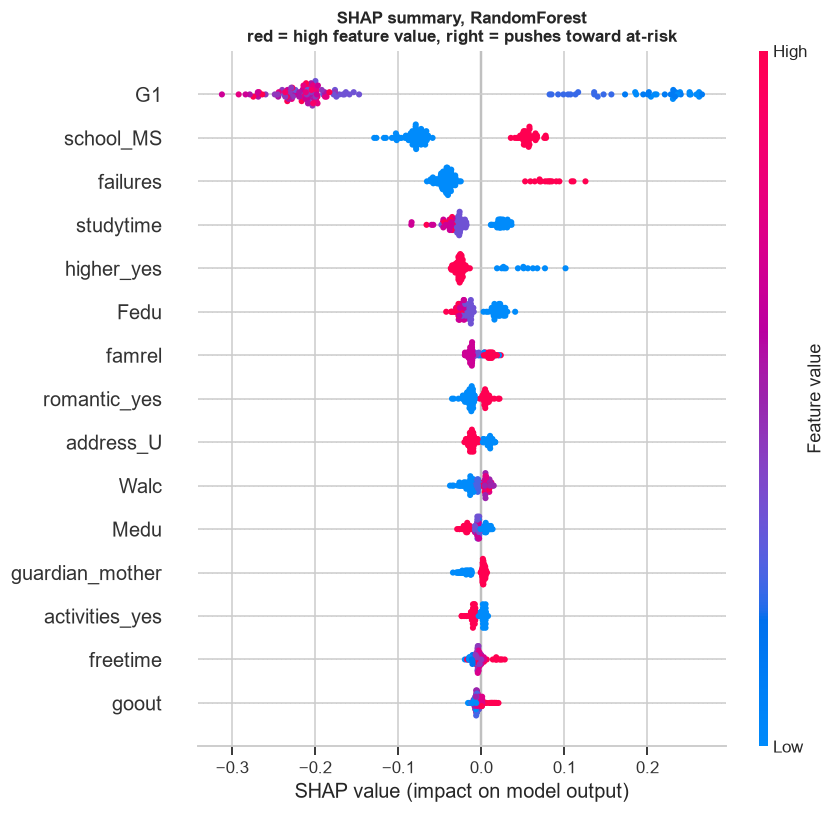

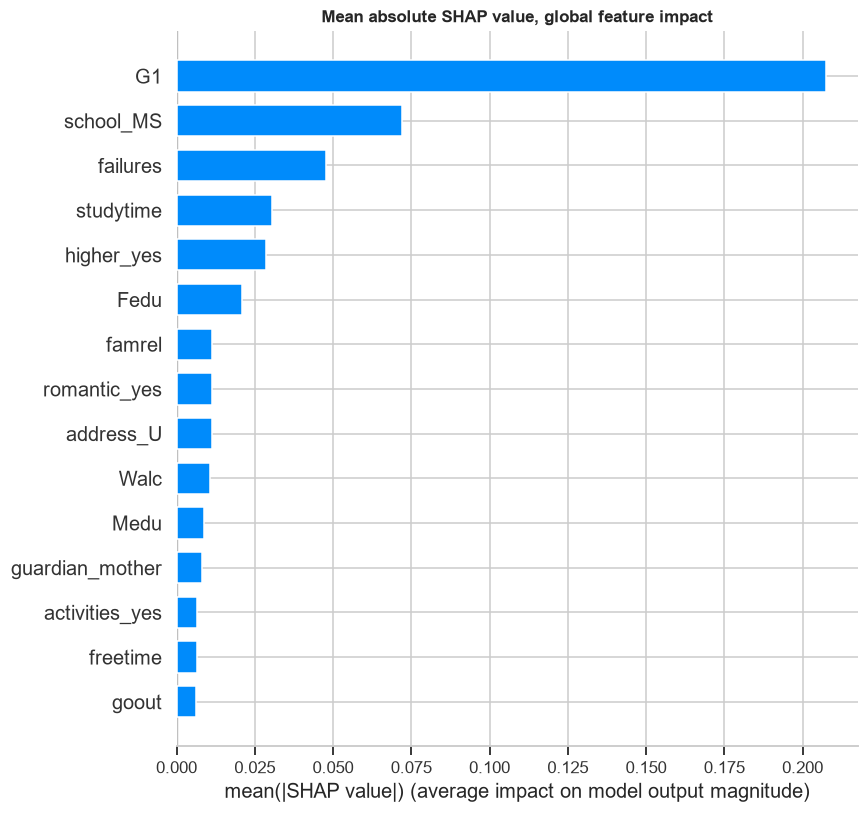

In [28]:
# SHAP. TreeExplainer for tree ensembles, otherwise the model-agnostic explainer.
is_tree = hasattr(clf, "estimators_") or hasattr(clf, "tree_")
if is_tree:
    explainer = shap.TreeExplainer(clf)
    raw = explainer.shap_values(X_test_enc)
    raw = np.asarray(raw)
    shap_pos = raw[:, :, 1] if raw.ndim == 3 else raw
    base_value = (explainer.expected_value[1]
                  if np.ndim(explainer.expected_value) > 0 else explainer.expected_value)
else:
    explainer = shap.LinearExplainer(clf, fitted_pre.transform(X_train))
    shap_pos = np.asarray(explainer.shap_values(X_test_enc))
    base_value = explainer.expected_value

shap_pos = np.asarray(shap_pos, dtype=float)
print(f"SHAP values: {shap_pos.shape} | base value {float(base_value):.4f}")
check("SHAP matrix matches the encoded test matrix",
      shap_pos.shape == X_test_enc.shape, f"{shap_pos.shape} vs {X_test_enc.shape}")

plt.figure()
shap.summary_plot(shap_pos, X_test_enc, feature_names=pretty_names, max_display=15, show=False)
plt.title(f"SHAP summary, {best_name}\nred = high feature value, right = pushes toward at-risk",
          fontsize=11, fontweight="bold")
plt.tight_layout(); plt.savefig(PLOT_DIR / "10_shap_summary.png"); plt.show()

plt.figure()
shap.summary_plot(shap_pos, X_test_enc, feature_names=pretty_names,
                  plot_type="bar", max_display=15, show=False)
plt.title("Mean absolute SHAP value, global feature impact", fontsize=11, fontweight="bold")
plt.tight_layout(); plt.savefig(PLOT_DIR / "11_shap_global_bar.png"); plt.show()

### 8.1 Explaining one student

This is exactly what the Streamlit app renders for a teacher: the risk band, plus the specific
factors that pushed this student's score up or down. We pick the highest-risk student in the
test set to demonstrate.

--- Student 512 (highest-risk in the test set) ---
Predicted probability of being at risk : 0.840
Risk band                              : High
Actual proxy label                     : AT RISK

Key inputs: G1=7, absences=9, failures=1, studytime=2, Medu=1, Fedu=1, higher=yes

--- top contributing factors (SHAP, log-odds scale) ---
  RAISES  risk  G1                       +0.2088
  RAISES  risk  failures                 +0.0829
  RAISES  risk  school_MS                +0.0779
  lowers  risk  Walc                     -0.0250
  RAISES  risk  Fedu                     +0.0242
  lowers  risk  studytime                -0.0177
  lowers  risk  higher_yes               -0.0138
  lowers  risk  famrel                   -0.0126


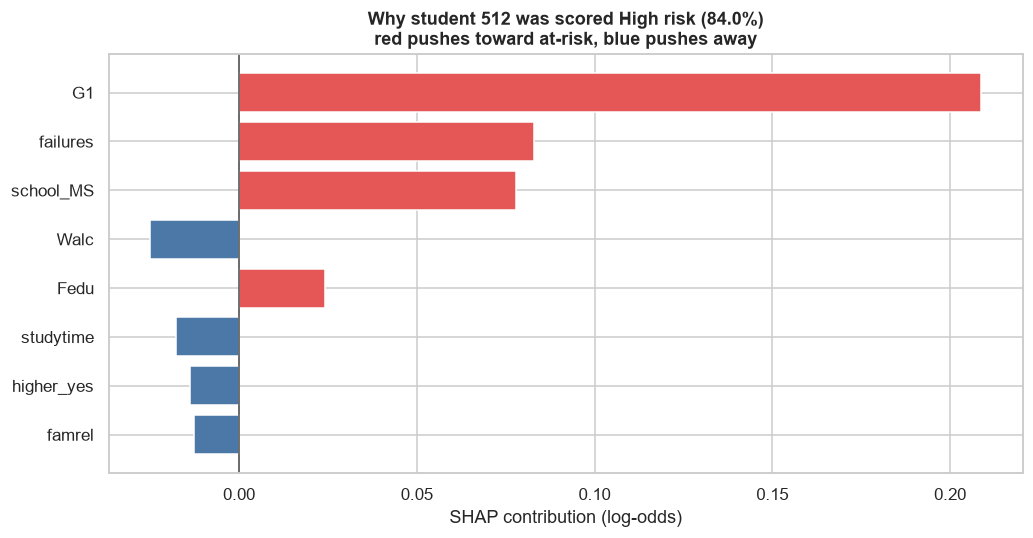

  [PASS] Risk band matches the configured cutoffs -> band=High, p=0.840


In [29]:
def explain_student(i):
    '''Return the risk score, band, and signed top factors for test-set row i.'''
    p = float(best_proba[i])
    contrib = pd.Series(shap_pos[i], index=pretty_names)
    top = contrib.reindex(contrib.abs().sort_values(ascending=False).index).head(8)
    return p, str(to_band(p)), top

idx = int(np.argmax(best_proba))
p, band, top = explain_student(idx)
student = X_test.iloc[idx]

print(f"--- Student {X_test.index[idx]} (highest-risk in the test set) ---")
print(f"Predicted probability of being at risk : {p:.3f}")
print(f"Risk band                              : {band}")
print(f"Actual proxy label                     : {'AT RISK' if y_test.iloc[idx] == 1 else 'not at risk'}")
print(f"\nKey inputs: G1={student['G1']}, absences={student['absences']}, "
      f"failures={student['failures']}, studytime={student['studytime']}, "
      f"Medu={student['Medu']}, Fedu={student['Fedu']}, higher={student['higher']}")

print("\n--- top contributing factors (SHAP, log-odds scale) ---")
for name, v in top.items():
    print(f"  {'RAISES ' if v > 0 else 'lowers '} risk  {name:<24} {v:+.4f}")

fig, ax = plt.subplots(figsize=(9.5, 5))
t = top[::-1]
ax.barh(t.index, t.values, color=["#E45756" if v > 0 else "#4C78A8" for v in t.values])
ax.axvline(0, color="0.3", lw=1)
ax.set_title(f"Why student {X_test.index[idx]} was scored {band} risk ({p:.1%})\n"
             "red pushes toward at-risk, blue pushes away")
ax.set_xlabel("SHAP contribution (log-odds)")
plt.tight_layout(); plt.savefig(PLOT_DIR / "12_shap_single_student.png"); plt.show()

check("Risk band matches the configured cutoffs",
      band == str(to_band(p)), f"band={band}, p={p:.3f}")

--- how the test cohort distributes across the risk bands ---
        students  actually_at_risk  share_of_cohort  precision_within_band
Low           92                 3             70.8                  0.033
Medium        32                13             24.6                  0.406
High           6                 4              4.6                  0.667

Of 20 genuinely at-risk students, 17 land in Medium or High.


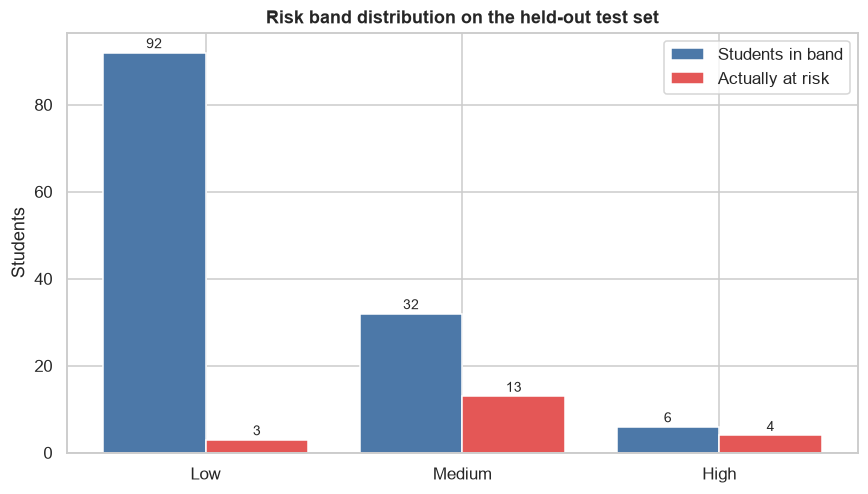

In [30]:
# Distribution of the cohort across the three risk bands, at the tuned threshold.
bands_test = pd.Series(to_band(best_proba), index=X_test.index)
summary = pd.DataFrame({
    "students": bands_test.value_counts(),
    "actually_at_risk": pd.Series(y_test.values, index=X_test.index).groupby(bands_test).sum(),
}).reindex(["Low", "Medium", "High"]).fillna(0).astype(int)
summary["share_of_cohort"] = (summary["students"] / len(bands_test) * 100).round(1)
summary["precision_within_band"] = (summary["actually_at_risk"] / summary["students"]).round(3)

print("--- how the test cohort distributes across the risk bands ---")
print(summary.to_string())
print(f"\nOf {int(y_test.sum())} genuinely at-risk students, "
      f"{int(summary.loc[['Medium','High'],'actually_at_risk'].sum())} land in Medium or High.")

fig, ax = plt.subplots(figsize=(8, 4.6))
x = np.arange(3)
ax.bar(x - 0.2, summary["students"], 0.4, label="Students in band", color="#4C78A8")
ax.bar(x + 0.2, summary["actually_at_risk"], 0.4, label="Actually at risk", color="#E45756")
ax.set_xticks(x); ax.set_xticklabels(summary.index)
ax.set_ylabel("Students"); ax.set_title("Risk band distribution on the held-out test set")
ax.legend()
for i, (n, a) in enumerate(zip(summary["students"], summary["actually_at_risk"])):
    ax.text(i - 0.2, n + 1, str(n), ha="center", fontsize=9)
    ax.text(i + 0.2, a + 1, str(a), ha="center", fontsize=9)
plt.tight_layout(); plt.savefig(PLOT_DIR / "13_risk_bands.png"); plt.show()

summary.to_csv(EVAL_DIR / "risk_band_summary.csv")

### 8.2 Sensitivity check: how much does each input actually move the score?

Importance rankings say which features the model *uses*. This says what a teacher would
actually see when they change one box in the app. We hold a modal student fixed and sweep one
feature at a time. This is the most direct test of whether the tool behaves the way its
interface implies.

Modal student: {'G1': 11, 'absences': 2, 'failures': 0, 'studytime': 2, 'higher': 'yes'}
Baseline score: 0.003



G1 (first-term grade)
   4=0.436  6=0.440  8=0.417  9=0.290  10=0.011  12=0.003  14=0.003  16=0.003  18=0.003


absences (days missed)
   0=0.000  2=0.003  4=0.003  8=0.004  12=0.002  16=0.008  24=0.031  32=0.031


failures (past)
   0=0.003  1=0.148  2=0.195  3=0.196


studytime
   1=0.011  2=0.003  3=0.007  4=0.007

--- how far each input can move the score, on its own ---
                        min_score  max_score  swing
feature                                            
G1 (first-term grade)       0.003      0.440  0.437
failures (past)             0.003      0.196  0.193
absences (days missed)      0.000      0.031  0.031
studytime                   0.003      0.011  0.008


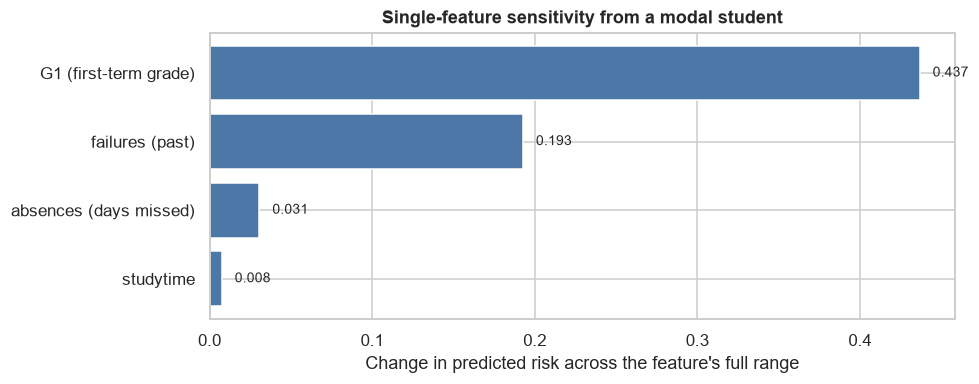


Honest read: moving absences across its entire 0 to 32 range shifts the score by 0.031, while G1 alone shifts it by 0.437.
The interface asks for attendance, and attendance genuinely belongs in an early-warning
system, but in THIS dataset it barely moves the prediction. Section 10 and the README
both record this as the project's headline limitation.
  [PASS] Sensitivity sweep produced a result for every feature


In [31]:
modal = {}
for c in num_features:
    modal[c] = int(df[c].median())
for c in cat_features:
    modal[c] = df[c].mode()[0]

def score_with(**override):
    row = dict(modal); row.update(override)
    return float(best_model.predict_proba(pd.DataFrame([row])[list(X.columns)])[0, 1])

print("Modal student:", {k: modal[k] for k in ["G1", "absences", "failures", "studytime", "higher"]})
print(f"Baseline score: {score_with():.3f}\n")

sweeps = {
    "G1 (first-term grade)": ("G1", [4, 6, 8, 9, 10, 12, 14, 16, 18]),
    "absences (days missed)": ("absences", [0, 2, 4, 8, 12, 16, 24, 32]),
    "failures (past)": ("failures", [0, 1, 2, 3]),
    "studytime": ("studytime", [1, 2, 3, 4]),
}
rows = []
for label, (col, values) in sweeps.items():
    scores = [score_with(**{col: v}) for v in values]
    rows.append({"feature": label, "min_score": min(scores), "max_score": max(scores),
                 "swing": max(scores) - min(scores)})
    print(f"{label}")
    print("   " + "  ".join(f"{v}={s:.3f}" for v, s in zip(values, scores)))

swing = pd.DataFrame(rows).set_index("feature").sort_values("swing", ascending=False)
print("\n--- how far each input can move the score, on its own ---")
print(swing.round(3).to_string())

fig, ax = plt.subplots(figsize=(9, 3.6))
ax.barh(swing.index[::-1], swing["swing"][::-1], color="#4C78A8")
ax.set_xlabel("Change in predicted risk across the feature's full range")
ax.set_title("Single-feature sensitivity from a modal student")
for i, v in enumerate(swing["swing"][::-1]):
    ax.text(v + 0.008, i, f"{v:.3f}", va="center", fontsize=9)
plt.tight_layout(); plt.savefig(PLOT_DIR / "14_sensitivity.png"); plt.show()

abs_swing = float(swing.loc["absences (days missed)", "swing"])
g1_swing = float(swing.loc["G1 (first-term grade)", "swing"])
print(f"\nHonest read: moving absences across its entire 0 to 32 range shifts the score by "
      f"{abs_swing:.3f}, while G1 alone shifts it by {g1_swing:.3f}.")
print("The interface asks for attendance, and attendance genuinely belongs in an early-warning")
print("system, but in THIS dataset it barely moves the prediction. Section 10 and the README")
print("both record this as the project's headline limitation.")
check("Sensitivity sweep produced a result for every feature", len(swing) == len(sweeps))

## 9. Saving the model and pipeline

In [32]:
section("STAGE 8: PERSISTENCE")

artifact = {
    "pipeline": best_model,              # preprocessing + SMOTE + classifier, one object
    "model_name": best_name,
    "is_tree_model": bool(is_tree),
    "feature_names_raw": list(X.columns),
    "feature_names_encoded": enc_names,
    "numeric_features": num_features,
    "categorical_features": cat_features,
    "categorical_levels": {c: sorted(df[c].unique().tolist()) for c in cat_features},
    "categorical_modes": {c: df[c].mode()[0] for c in cat_features},
    "numeric_ranges": {c: [float(df[c].min()), float(df[c].max())] for c in num_features},
    "numeric_medians": {c: float(df[c].median()) for c in num_features},
    "sensitivity_swings": {k: float(v) for k, v in swing["swing"].items()},
    "config": CONFIG,
    "tuned_threshold": float(tuned_threshold),
    "shap_base_value": float(base_value),
    "test_metrics_tuned": {k: float(v) for k, v in tuned_metrics.items()},
    "test_metrics_default": {k: float(v) for k, v in default_metrics.items()},
    "training_rows": int(len(X_train)),
    "target_definition": f"at_risk = 1 if G3 < {CONFIG['pass_mark']} (proxy, not observed dropout)",
    "sklearn_version": __import__("sklearn").__version__,
}

MODEL_PATH = MODEL_DIR / "dropout_risk_model.joblib"
joblib.dump(artifact, MODEL_PATH, compress=3)
size_kb = MODEL_PATH.stat().st_size / 1024
print(f"Saved {MODEL_PATH} ({size_kb:.0f} KB)")

reloaded = joblib.load(MODEL_PATH)
round_trip = reloaded["pipeline"].predict_proba(X_test)[:, 1]
print(f"Reload check: max probability difference = {np.abs(round_trip - best_proba).max():.2e}")

check("Reloaded pipeline reproduces predictions exactly",
      np.allclose(round_trip, best_proba), "joblib round trip changed the predictions")
check("Artifact carries everything the app needs",
      all(k in reloaded for k in ["pipeline", "tuned_threshold", "categorical_levels",
                                  "numeric_medians", "config", "is_tree_model"]))
check("Saved threshold is usable", 0 < reloaded["tuned_threshold"] < 1)


STAGE 8: PERSISTENCE


Saved C:\Users\USER\OneDrive\Desktop\capstone project\models\dropout_risk_model.joblib (827 KB)


Reload check: max probability difference = 2.22e-16
  [PASS] Reloaded pipeline reproduces predictions exactly -> joblib round trip changed the predictions
  [PASS] Artifact carries everything the app needs
  [PASS] Saved threshold is usable


In [33]:
# Machine-readable metrics for the README and the app.
report = {
    "dataset": {
        "source": "UCI Student Performance (Cortez & Silva 2008), Portuguese-language cohort",
        "url": "https://archive.ics.uci.edu/dataset/320/student+performance",
        "students": int(len(df)),
        "raw_features": int(X.shape[1]),
        "encoded_features": int(len(enc_names)),
        "at_risk_count": int(y.sum()),
        "at_risk_rate": float(y.mean()),
    },
    "target": {
        "definition": f"at_risk = 1 if G3 < {CONFIG['pass_mark']} of {CONFIG['grade_scale_max']}",
        "nature": "proxy label for end-of-year academic failure, not observed dropout",
        "excluded_for_leakage": CONFIG["leaky_features"],
    },
    "split": {"train": int(len(X_train)), "test": int(len(X_test)),
              "train_at_risk": int(y_train.sum()), "test_at_risk": int(y_test.sum())},
    "best_model": best_name,
    "selection_rule": "highest cross-validated PR-AUC on the training folds",
    "tuned_threshold": float(tuned_threshold),
    "threshold_rule": rule,
    "risk_bands": CONFIG["risk_bands"],
    "metrics_default_threshold": {k: float(v) for k, v in default_metrics.items()},
    "metrics_tuned_threshold": {k: float(v) for k, v in tuned_metrics.items()},
    "all_models": json.loads(comparison.to_json(orient="index")),
    "top_permutation_features": perm_imp.head(10).round(5).to_dict(),
    "risk_band_summary": json.loads(summary.to_json(orient="index")),
}

with open(EVAL_DIR / "metrics.json", "w") as f:
    json.dump(report, f, indent=2)
print(f"Saved {EVAL_DIR / 'metrics.json'}")

plots = sorted(p.name for p in PLOT_DIR.glob("*.png"))
print(f"\nSaved {len(plots)} plots:")
for p in plots:
    print("  " + p)

section("PIPELINE COMPLETE")
print(f"Best model            : {best_name}")
print(f"Tuned threshold       : {tuned_threshold:.3f}")
print(f"Test recall (at-risk) : {tuned_metrics['recall']:.3f}")
print(f"Test precision        : {tuned_metrics['precision']:.3f}")
print(f"Test ROC-AUC          : {tuned_metrics['roc_auc']:.3f}")
print(f"Test PR-AUC           : {tuned_metrics['pr_auc']:.3f}")
print(f"At-risk students missed: {tuned_metrics['fn']} of {int(y_test.sum())}")
check("At least 4 plots were saved, as required", len(plots) >= 4, f"only {len(plots)}")
check("Model file exists on disk", MODEL_PATH.exists())
check("Metrics file exists on disk", (EVAL_DIR / "metrics.json").exists())
print("\nAll stages validated. Artifacts are ready for app.py.")

Saved C:\Users\USER\OneDrive\Desktop\capstone project\evaluation\metrics.json

Saved 14 plots:
  01_target_and_inputs.png
  02_attendance_grades_vs_target.png
  03_correlations.png
  04_socioeconomic_factors.png
  05_roc_pr_curves.png
  06_confusion_matrices.png
  07_threshold_tuning.png
  08_model_comparison.png
  09_feature_importance.png
  10_shap_summary.png
  11_shap_global_bar.png
  12_shap_single_student.png
  13_risk_bands.png
  14_sensitivity.png

PIPELINE COMPLETE
Best model            : RandomForest
Tuned threshold       : 0.420
Test recall (at-risk) : 0.850
Test precision        : 0.567
Test ROC-AUC          : 0.890
Test PR-AUC           : 0.581
At-risk students missed: 3 of 20
  [PASS] At least 4 plots were saved, as required -> only 14
  [PASS] Model file exists on disk
  [PASS] Metrics file exists on disk

All stages validated. Artifacts are ready for app.py.


---

## Summary and honest caveats

**What was built.** A model that scores a secondary-school student's risk of finishing the year
below the pass mark, maps it to a Low / Medium / High band, and explains each individual score
with SHAP. It is tuned for recall on the at-risk class, because missing a student who needed
help is far more costly than reviewing one who did not.

**What it is not.**

1. **The target is a proxy.** It is end-of-year academic failure, a documented precursor of
   dropout, not observed dropout. A student who leaves for reasons unrelated to grades is
   invisible to this label.
2. **The data is Portuguese, not Nigerian.** No public student-level Nigerian secondary-school
   dataset with a dropout outcome was found. The socioeconomic drivers of dropout in Nigeria
   differ, so the coefficients should not be trusted as-is for Nigerian schools. The pipeline
   is the transferable artefact, not the fitted weights.
3. **Attendance is a weaker signal here than expected.** The at-risk rate does climb with
   absences, but prior academic performance dominates. A Nigerian dataset with term-by-term
   attendance would very likely change this.
4. **It must stay human-in-the-loop.** Several features are socioeconomic proxies. The output
   is a prompt for a teacher to look closer, never a basis for streaming, penalising, or
   excluding a student. See the Ethics section of the README.